# Proyecto Aprendizaje Automático

- Nombre: Héctor Fernández Cano
- Nombre: Diego José García Callejas


En primer lugar, leeremos el fichero csv para poder analizarlo y sacar las primeras conclusiones

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_samples
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib as mpl
from sklearn.metrics import silhouette_score, adjusted_rand_score
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn import preprocessing
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV
from google.colab import drive

In [14]:
#Leemos los datos y hacemos una copia para no modificar el original
#data_odd=pd.read_csv("data-odd.csv")
#data_odd=data_odd.copy()
file_id = '1LbR-d6kvX7h5HXLFZCmHLSD_uwo2ZbMQ'
url = f'https://drive.google.com/uc?id={file_id}'
data_odd = pd.read_csv(url)
data_odd

,Age,Education,EducationNum,MaritalStatus,Relationship,Gender,CapitalGain,HoursPerWeek
0,38,HS-grad,9,Divorced,Not-in-family,Male,0,40
1,53,11th,7,Married-civ-spouse,Husband,Male,0,40
2,28,Bachelors,13,Married-civ-spouse,Wife,Female,0,40
3,37,Masters,14,Married-civ-spouse,Wife,Female,0,40
4,49,9th,5,Married-spouse-absent,Not-in-family,Female,0,16
...,...,...,...,...,...,...,...,...
22691,22,Some-college,10,Never-married,Not-in-family,Male,0,40
22692,27,Assoc-acdm,12,Married-civ-spouse,Wife,Female,0,38
22693,40,HS-grad,9,Married-civ-spouse,Husband,Male,0,40
22694,58,HS-grad,9,Widowed,Unmarried,Female,0,40


In [15]:
#Función para graficar el silhouette score
def plot_silhouette(model, X):
    mu = model.cluster_centers_
    K, D = mu.shape
    y_pred = model.labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)
    silhouette_scores = silhouette_score(X, model.labels_)
    cmap = plt.get_cmap("Pastel2")
    colors = [cmap(i) for i in range(K)]
    padding = len(X) // 30
    pos = padding
    for i in range(K):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()
        color = mpl.cm.Spectral(i / K)
        # color = colors[i]
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs, facecolor=color, edgecolor=color, alpha=0.7)
        pos += len(coeffs) + padding
    score = silhouette_scores
    plt.axvline(x=score, color="red", linestyle="--")
    plt.title("$k={}, score={:0.2f}$".format(K, score), fontsize=16)

In [16]:
#Obsevamos las primeras filas
print(data_odd.head())

   Age   Education  EducationNum           MaritalStatus    Relationship  \
0   38     HS-grad             9                Divorced   Not-in-family   
1   53        11th             7      Married-civ-spouse         Husband   
2   28   Bachelors            13      Married-civ-spouse            Wife   
3   37     Masters            14      Married-civ-spouse            Wife   
4   49         9th             5   Married-spouse-absent   Not-in-family   

    Gender  CapitalGain  HoursPerWeek  
0     Male            0            40  
1     Male            0            40  
2   Female            0            40  
3   Female            0            40  
4   Female            0            16  


In [17]:
#Visualizamos información estadística de las variables numéricas
data_odd.describe()

,Age,EducationNum,CapitalGain,HoursPerWeek
count,22696.000000,22696.000000,22696.000000,22696.000000
mean,36.797585,9.879714,889.217792,40.267096
std,12.827721,2.495500,6424.267599,11.256298
min,17.000000,1.000000,0.000000,1.000000
25%,26.000000,9.000000,0.000000,40.000000
50%,35.000000,10.000000,0.000000,40.000000
75%,45.000000,11.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,99.000000


A partir de ahora realizaramos los pasos necesarios para poder preprocesar el dataframe

In [18]:
#Comprobamos si existe algún nulo
data_odd.isnull().sum()


,0
Age,0
Education,0
EducationNum,0
MaritalStatus,0
Relationship,0
Gender,0
CapitalGain,0
HoursPerWeek,0


Como se puede ver, no tenemos datos nulos en ninguna de nuestras columnas del dataframe, por lo que pasaremos ahora a comprobar el número de filas duplicadas que pudiesen exisitir.

In [19]:
print(data_odd.duplicated().sum())

10135


Hemos obtenido 10135 filas repetidas, es decir, existen personas que tienen todas sus características idénticas. Eliminamos las respectivas filas duplicadas

In [20]:
data_odd = data_odd.drop_duplicates().reset_index(drop=True)
#Comprobamos si se han eliminado  los duplicados
print(data_odd.duplicated().sum())

0


Una vez acabada esta parte, procederemos al análisis de cada una de las variables

## 2. Análisis de  las variables

En esta parte procederemos al análisis de cada variable, de  manera que podamos observar los posibles valores que pueden tomar y en que cantidad lo hacen

#### 1. Age

La primera variable que analizaremos sera Age, la cual hemos comprobado anteriormente que es una variable numérica que toma valores entre 17 y 90

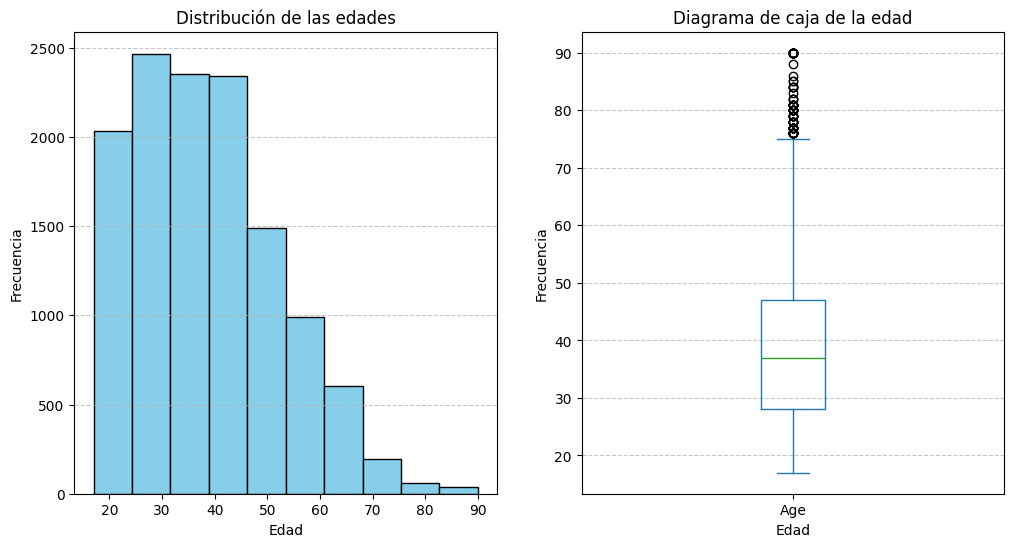

In [21]:
plt.figure(figsize=(12, 6))
ax1=plt.subplot(1,2,1)
#Realizamos el histograma de la variable Age

data_odd['Age'].plot(
    kind='hist',
    title='Distribución de las edades',
    color='skyblue',
    edgecolor='black',
    ax=ax1
)
ax1.set_title('Distribución de las edades')
ax1.set_xlabel('Edad')
ax1.set_ylabel('Frecuencia')
ax1.grid(axis='y', linestyle='--', alpha=0.7)


ax2=plt.subplot(1,2,2)
#Realizamos el diagrama de caja de la variable Age
data_odd['Age'].plot(
    kind='box',
    ax=ax2,

)

ax2.set_title('Diagrama de caja de la edad')
ax2.set_xlabel('Edad')
ax2.set_ylabel('Frecuencia')
ax2.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

A partir del histograma podemos ver que la mayoria de edades está entre 17 y 45 años, y a medida que aumentamos esta, los valores van dismimuyendo, por lo que podemos ver que para el estudio se han cogido a personas jóvenes o adultas. Aquellas edades que pasan de 75 años, son consideramos por el diagrama de cajas como outliers, aunque más adelante veremos que hacer con ellas

#### 2. Education

La segunda variable que analizaremos sera Education, nuestra primera variable categórica, la cual nos indica el grado de estudio de los sujetos

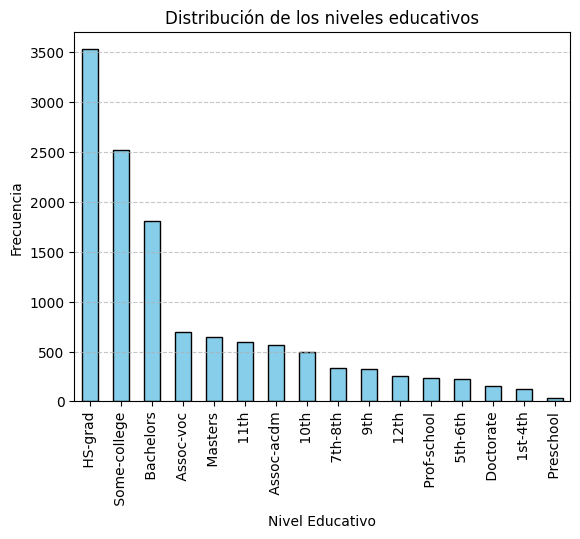

In [22]:
#Realizamos el histograma de la variable Education
data_odd['Education'].value_counts().plot(
    kind='bar',
    title='Distribución de los niveles educativos',
    color='skyblue',
    edgecolor='black'
)

plt.xlabel('Nivel Educativo')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



En esta caso, podemos observar que la mayoria de gente dispone de un nivel educativo 'HS-grad', mientras que muy pocos solo disponen del nivel 'Preschool', por lo que se podría decir que bastantes personas tienen cierto nivel educativo

#### 3. EducationNum

En este caso, el nombre de la variable y el análisis anterior nos incita a dudar de la simulitud de esta variable con la anterior ('Education'). Comprobamos

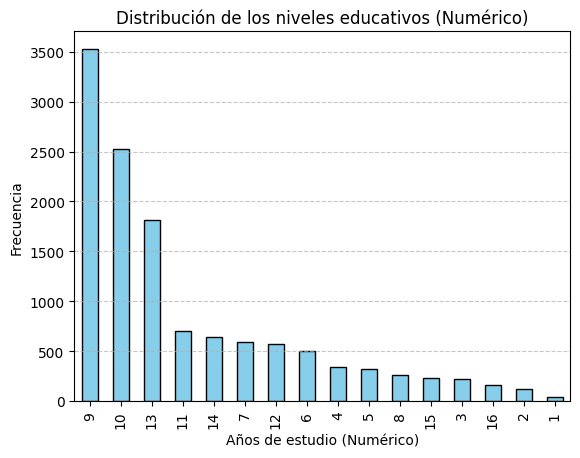

In [23]:
#Realizamos el histograma de la variable EducationNum
data_odd['EducationNum'].value_counts().plot(
    kind='bar',
    title='Distribución de los niveles educativos (Numérico)',
    color='skyblue',
    edgecolor='black'
)

plt.xlabel('Años de estudio (Numérico)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

En este caso, utilizamos una gráfica tipo bar, para observar que efectivamente, la variable Age y la variable EducationNum, son la misma solo que una es categórica, mientras que la variable EducationNum es ordinal. Esta coincidencia nos llevará más adelante a eliminar una de las dos variables para evitar la redundancia.

#### 4. MaritalStatus

Procedemos a estudiar ahora la variable 'MaritalStatus', la cual es cuantitativa y nos dara información sobre el estado civil de cada sujeto

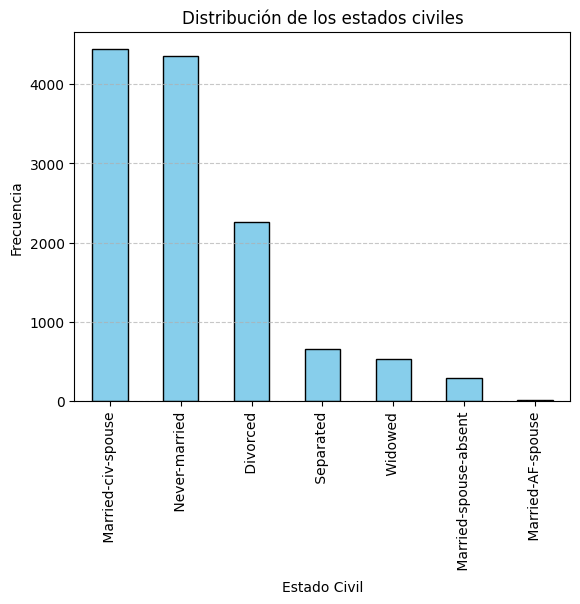

In [24]:
#Realizamos el histograma de la variable MaritalStatus
data_odd['MaritalStatus'].value_counts().plot(
    kind='bar',
    title='Distribución de los estados civiles',
    color='skyblue',
    edgecolor='black'
)

plt.xlabel('Estado Civil')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Las diferentes categorías son:
 - **Married-civ-spouse**: casado/a con pareja civil.
 - **Never-married**: nunca casado/a.
 - **Divorced**: divorciado/a
 - **Separated**: separado/a (aún casado).
 - **Widowed**: viudo/a.
 - **Married-spouse-absent**: casado/a pero la pareja no vive en el hogar
 -**Married-AF-spouse**: casado/a con una pareja en las Fuerzas Armadas.

 Se puede observar que las categorías que más predominan son los casodos/as y aquellos que nunca se han casado.

#### 5. Relationship

Nos centramos en estos momentos en la variable 'Relationship', nuestra tercera variable categórica, que nos informa sobre el rol que tiene dicha persona en su hogar


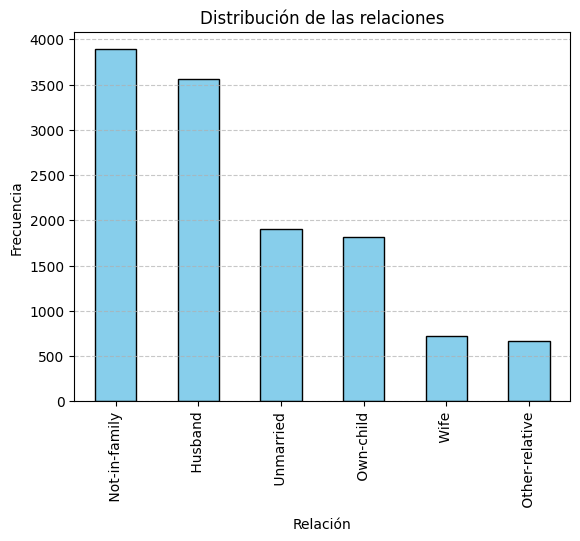

In [25]:
#Realizamos el histograma de la variable Relationship
data_odd['Relationship'].value_counts().plot(
    kind='bar',
    title='Distribución de las relaciones',
    color='skyblue',
    edgecolor='black'
)

plt.xlabel('Relación')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Como era de esperar, las personas que nunca se han casado, no forman una familia, luego no disponen de rol en esta. Este pequeño dato nos podría llegar a hacer pensar que esta variable esta relacionada de alguna con la variable MaritalStatus.
Otro dato sorprendente, es que la mayoria de personas toman el rol de 'marido', luego veremos ahora con la variable 'Gender', si la mayor parte de los sujetos son hombres.

#### 6. Gender

Como ya adelantamos, es el turno de la variable 'Gender', que nos informará del género de lo sujetos a los que les hemos tomado los datos

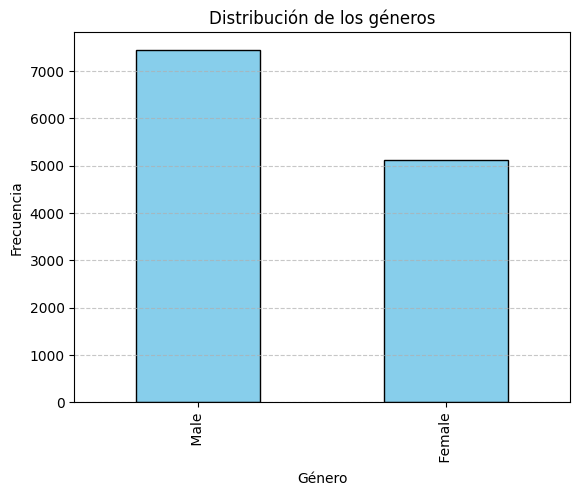

In [26]:
#Realizamos el histograma de la variable Gender
data_odd['Gender'].value_counts().plot(
    kind='bar',
    title='Distribución de los géneros',
    color='skyblue',
    edgecolor='black'
)

plt.xlabel('Género')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Efectivamente, como hemos podido intuir con la variable anterior, la mayor parte de los datos son procedentes de sujetos de género masculino.

#### 7. CapitalGain

Antes de llegar a la última variable, procedemos al análisis de la variable 'CapitalGain', la cual tenía unos valores estadísticos un poco extraños.

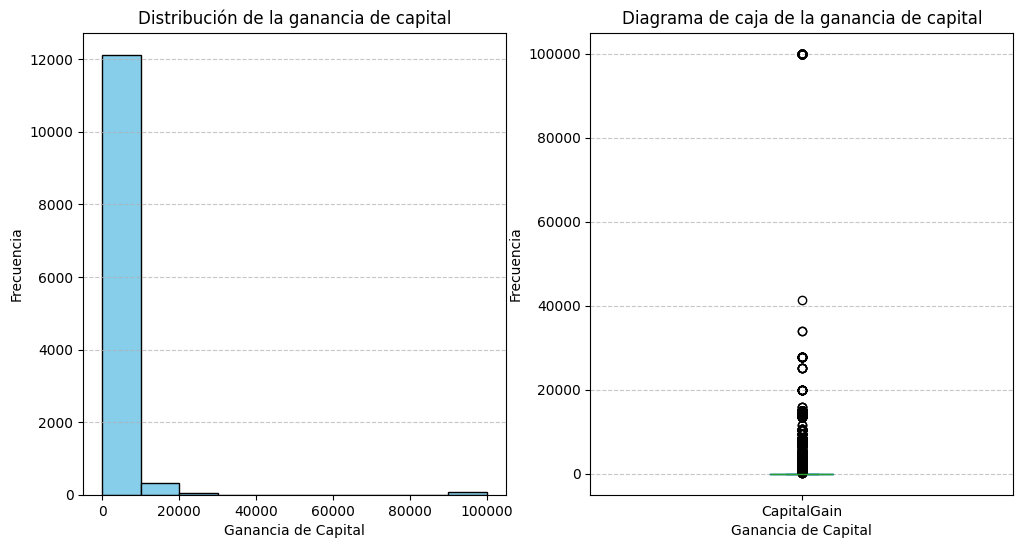

In [27]:
plt.figure(figsize=(12, 6))
ax1=plt.subplot(1,2,1)
#Realizamos el histograma de la variable CapitalGain

data_odd['CapitalGain'].plot(
    kind='hist',
    title='Distribución de la ganancia de capital',
    color='skyblue',
    edgecolor='black',
    ax=ax1
)
ax1.set_title('Distribución de la ganancia de capital')
ax1.set_xlabel('Ganancia de Capital')
ax1.set_ylabel('Frecuencia')
ax1.grid(axis='y', linestyle='--', alpha=0.7)


ax2=plt.subplot(1,2,2)
#Realizamos el diagrama de caja de la variable CapitalGain
data_odd['CapitalGain'].plot(
    kind='box',
    ax=ax2,

)

ax2.set_title('Diagrama de caja de la ganancia de capital')
ax2.set_xlabel('Ganancia de Capital')
ax2.set_ylabel('Frecuencia')
ax2.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Los valores de esta variable  son un tanto extraños, siendo la mayor totalidad de estos 0 y unos muy pocos, mayores que 0, incluso podemos observar un valor que se aleja completamente de los demas, siendo este un outlier bastante claro, el cual más adelante, ya pensaremos que haremos con él

#### 8. HoursPerWeek

Por útimo y para terminar el análisis de las variables procedemos con la variable 'HoursPerweeK', la cual nos indica las horas que trabaja cada sujeto.

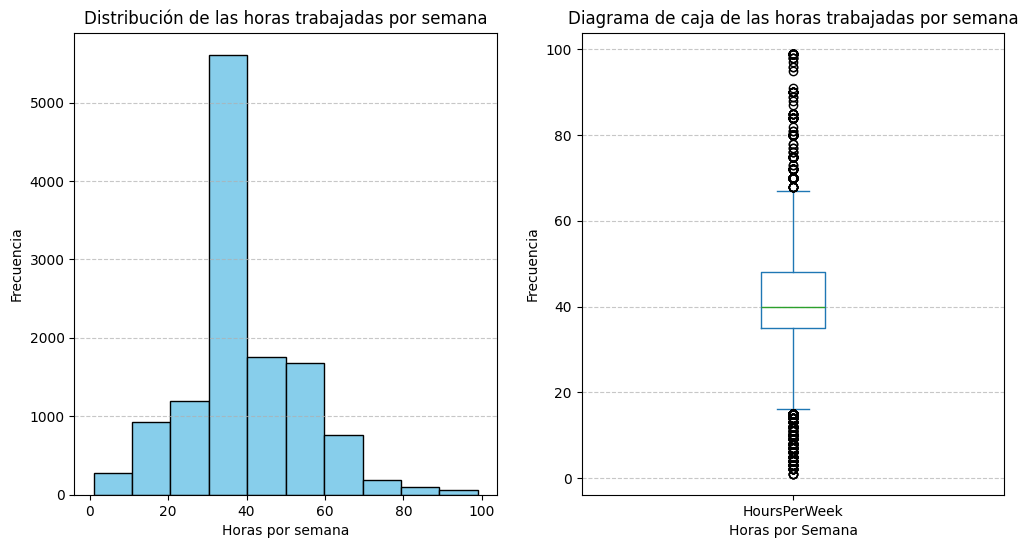

In [28]:
plt.figure(figsize=(12, 6))
ax1=plt.subplot(1,2,1)
#Realizamos el histograma de la variable HoursPerWeek

data_odd['HoursPerWeek'].plot(
    kind='hist',
    title='Distribución de las horas trabajadas por semana',
    color='skyblue',
    edgecolor='black',
    ax=ax1
)
ax1.set_title('Distribución de las horas trabajadas por semana')
ax1.set_xlabel('Horas por semana')
ax1.set_ylabel('Frecuencia')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

ax2=plt.subplot(1,2,2)

#Realizamos el diagrama de caja de la variable HoursPerWeek
data_odd['HoursPerWeek'].plot(
    kind='box',
    ax=ax2,

)

ax2.set_title('Diagrama de caja de las horas trabajadas por semana')
ax2.set_xlabel('Horas por Semana')
ax2.set_ylabel('Frecuencia')
ax2.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

La mayor parte de los datos se encuentra entre las 40 horas. Podemos observar numerosos datos que se alejan de los valores centreales, por lo que lo normal es trabajar 40 horas semanales.

## 3. Escalado de variables

Tras tener todos los datos sin nulos, procedemos a separar el dataframe en categorías cuantitativas y en categóricas

In [29]:
categoricas_columns=['Education','MaritalStatus','Relationship','Gender']
cuantitativas_columns=['Age','EducationNum','CapitalGain','HoursPerWeek']
data_odd_categorical=data_odd[categoricas_columns]
data_odd_cuantitative=data_odd[cuantitativas_columns]
data_odd_cuantitative.head()


,Age,EducationNum,CapitalGain,HoursPerWeek
0,38,9,0,40
1,53,7,0,40
2,28,13,0,40
3,37,14,0,40
4,49,5,0,16


In [30]:
data_odd_categorical.head()

,Education,MaritalStatus,Relationship,Gender
0,HS-grad,Divorced,Not-in-family,Male
1,11th,Married-civ-spouse,Husband,Male
2,Bachelors,Married-civ-spouse,Wife,Female
3,Masters,Married-civ-spouse,Wife,Female
4,9th,Married-spouse-absent,Not-in-family,Female


In [31]:
#Quitamos Education para hacer OneHotEncoding y dejamos esta variable para hacer OrdinalEncoder
data_odd_categorical_sin_education= data_odd_categorical[categoricas_columns[1:]]

#Aplicamos OneHotEncoder
one_hot= preprocessing.OneHotEncoder(drop= 'first', handle_unknown= 'ignore', sparse_output= False)
one_hot.fit(data_odd_categorical_sin_education)
categoricas_one_hot= one_hot.transform(data_odd_categorical_sin_education)

#Aplicamos OrdinalEncoder
#Definimos el orden de la variable Education para que sepa como ordenarla
order = [[' Preschool', ' 1st-4th',' 5th-6th',' 7th-8th', ' 9th',' 10th',' 11th',' 12th',  ' HS-grad',
           ' Some-college', ' Assoc-acdm', ' Assoc-voc',  ' Bachelors', ' Masters',  ' Prof-school',  ' Doctorate']]

ord_encod= preprocessing.OrdinalEncoder(categories=order)
ord_encod.fit(data_odd_categorical[['Education']])
#Sumamos 1 para que empieze desde 1
education_ord= ord_encod.transform(data_odd_categorical[['Education']])+1

#Juntamos los datos transformados en un solo dataframe
columnas_one_hot= one_hot.get_feature_names_out(['MaritalStatus', 'Relationship', 'Gender'])
df_one_hot= pd.DataFrame(categoricas_one_hot, columns= columnas_one_hot, index=data_odd_categorical.index)
df_ord_enc= pd.DataFrame(education_ord, columns= ["Education_transformed"], index=data_odd_categorical.index)

categoricas_transformadas= pd.concat([df_one_hot, df_ord_enc], axis= 1)
categoricas_transformadas

,MaritalStatus_ Married-AF-spouse,MaritalStatus_ Married-civ-spouse,MaritalStatus_ Married-spouse-absent,MaritalStatus_ Never-married,MaritalStatus_ Separated,MaritalStatus_ Widowed,Relationship_ Not-in-family,Relationship_ Other-relative,Relationship_ Own-child,Relationship_ Unmarried,Relationship_ Wife,Gender_ Male,Education_transformed
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,9.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,7.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,13.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,14.0
4,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12556,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,13.0
12557,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,14.0
12558,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,14.0
12559,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,11.0


Unimos de nuevo los datos para proceder con el resto del preproceso

In [32]:
df_data_odd_all_cuantitative= pd.concat([data_odd_cuantitative, categoricas_transformadas], axis=1)
df_data_odd_all_cuantitative

,Age,EducationNum,CapitalGain,HoursPerWeek,MaritalStatus_ Married-AF-spouse,MaritalStatus_ Married-civ-spouse,MaritalStatus_ Married-spouse-absent,MaritalStatus_ Never-married,MaritalStatus_ Separated,MaritalStatus_ Widowed,Relationship_ Not-in-family,Relationship_ Other-relative,Relationship_ Own-child,Relationship_ Unmarried,Relationship_ Wife,Gender_ Male,Education_transformed
0,38,9,0,40,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,9.0
1,53,7,0,40,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,7.0
2,28,13,0,40,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,13.0
3,37,14,0,40,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,14.0
4,49,5,0,16,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12556,38,13,15020,45,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,13.0
12557,31,14,0,30,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,14.0
12558,32,14,0,11,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,14.0
12559,27,12,0,38,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,11.0


Tenemos la intuicion de que Education es redundante ya que EducationNum es igual para todas las instancias que tienen una determinada Education

In [33]:
df_education_redundance= df_data_odd_all_cuantitative.groupby('Education_transformed')['EducationNum'].unique()
df_education_redundance

,EducationNum
Education_transformed,
1.0,[1]
2.0,[2]
3.0,[3]
4.0,[4]
5.0,[5]
6.0,[6]
7.0,[7]
8.0,[8]
9.0,[9]


Como vemos que todas son iguales decidimos eliminar la variable Education_transformed

In [34]:
df_data_odd_all_cuantitative.drop('Education_transformed', axis= 1, inplace= True)
df_data_odd_all_cuantitative

,Age,EducationNum,CapitalGain,HoursPerWeek,MaritalStatus_ Married-AF-spouse,MaritalStatus_ Married-civ-spouse,MaritalStatus_ Married-spouse-absent,MaritalStatus_ Never-married,MaritalStatus_ Separated,MaritalStatus_ Widowed,Relationship_ Not-in-family,Relationship_ Other-relative,Relationship_ Own-child,Relationship_ Unmarried,Relationship_ Wife,Gender_ Male
0,38,9,0,40,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,53,7,0,40,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,28,13,0,40,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,37,14,0,40,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,49,5,0,16,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12556,38,13,15020,45,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
12557,31,14,0,30,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
12558,32,14,0,11,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
12559,27,12,0,38,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


Procedemos a aplicar los diferentes procesos de escalado

- Estandarizado

In [35]:
scaler=preprocessing.StandardScaler().fit(df_data_odd_all_cuantitative)
print(scaler.mean_)
print(scaler.scale_)
df_data_odd_all_cuantitative_standart=scaler.transform(df_data_odd_all_cuantitative)
df_data_odd_all_cuantitative_standart= pd.DataFrame(df_data_odd_all_cuantitative_standart, columns= df_data_odd_all_cuantitative.columns, index= df_data_odd_all_cuantitative.index)
df_data_odd_all_cuantitative_standart.describe()

[3.85107874e+01 9.81052464e+00 1.54488528e+03 4.05009155e+01
 1.19417244e-03 3.53554653e-01 2.32465568e-02 3.46389619e-01
 5.27824218e-02 4.27513733e-02 3.09688719e-01 5.30212563e-02
 1.44654088e-01 1.51421065e-01 5.74795000e-02 5.92548364e-01]
[1.35508395e+01 2.83192993e+00 8.45617273e+03 1.32831001e+01
 3.45361606e-02 4.78072966e-01 1.50685614e-01 4.75819137e-01
 2.23598832e-01 2.02296054e-01 4.62365241e-01 2.24075886e-01
 3.51751735e-01 3.58458821e-01 2.32756540e-01 4.91360153e-01]


,Age,EducationNum,CapitalGain,HoursPerWeek,MaritalStatus_ Married-AF-spouse,MaritalStatus_ Married-civ-spouse,MaritalStatus_ Married-spouse-absent,MaritalStatus_ Never-married,MaritalStatus_ Separated,MaritalStatus_ Widowed,Relationship_ Not-in-family,Relationship_ Other-relative,Relationship_ Own-child,Relationship_ Unmarried,Relationship_ Wife,Gender_ Male
count,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04
mean,-2.353203e-16,5.317333e-17,7.919432e-18,-2.503106e-16,-8.202269e-18,2.715234e-17,1.131347e-17,2.234411e-17,3.620312e-17,3.507177e-17,3.394042e-17,4.299120e-17,-1.357617e-17,8.371971e-17,-3.563744e-17,5.543602e-17
std,1.000040e+00,1.000040e+00,1.000040e+00,1.000040e+00,1.000040e+00,1.000040e+00,1.000040e+00,1.000040e+00,1.000040e+00,1.000040e+00,1.000040e+00,1.000040e+00,1.000040e+00,1.000040e+00,1.000040e+00,1.000040e+00
min,-1.587414e+00,-3.111138e+00,-1.826932e-01,-2.973772e+00,-3.457745e-02,-7.395412e-01,-1.542719e-01,-7.279859e-01,-2.360586e-01,-2.113307e-01,-6.697924e-01,-2.366219e-01,-4.112392e-01,-4.224225e-01,-2.469512e-01,-1.205935e+00
25%,-7.756558e-01,-2.862093e-01,-1.826932e-01,-4.141289e-01,-3.457745e-02,-7.395412e-01,-1.542719e-01,-7.279859e-01,-2.360586e-01,-2.113307e-01,-6.697924e-01,-2.366219e-01,-4.112392e-01,-4.224225e-01,-2.469512e-01,-1.205935e+00
50%,-1.114903e-01,6.690680e-02,-1.826932e-01,-3.771074e-02,-3.457745e-02,-7.395412e-01,-1.542719e-01,-7.279859e-01,-2.360586e-01,-2.113307e-01,-6.697924e-01,-2.366219e-01,-4.112392e-01,-4.224225e-01,-2.469512e-01,8.292321e-01
75%,6.264713e-01,7.731390e-01,-1.826932e-01,5.645583e-01,-3.457745e-02,1.352190e+00,-1.542719e-01,1.373653e+00,-2.360586e-01,-2.113307e-01,1.493000e+00,-2.366219e-01,-4.112392e-01,-4.224225e-01,-2.469512e-01,8.292321e-01
max,3.799706e+00,2.185603e+00,1.164287e+01,4.404023e+00,2.892058e+01,1.352190e+00,6.482062e+00,1.373653e+00,4.236237e+00,4.731919e+00,1.493000e+00,4.226152e+00,2.431675e+00,2.367298e+00,4.049384e+00,8.292321e-01


- MinMaxScaler

In [36]:
minMaxScaler=preprocessing.MinMaxScaler().fit(df_data_odd_all_cuantitative)
print(minMaxScaler.data_min_)
print(minMaxScaler.data_range_)
df_data_odd_all_cuantitative_minMaxScaler=minMaxScaler.transform(df_data_odd_all_cuantitative)
df_data_odd_all_cuantitative_minMaxScaler= pd.DataFrame(df_data_odd_all_cuantitative_minMaxScaler, columns=df_data_odd_all_cuantitative.columns, index= df_data_odd_all_cuantitative.index)
df_data_odd_all_cuantitative_minMaxScaler.describe()

[17.  1.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
[7.3000e+01 1.5000e+01 9.9999e+04 9.8000e+01 1.0000e+00 1.0000e+00
 1.0000e+00 1.0000e+00 1.0000e+00 1.0000e+00 1.0000e+00 1.0000e+00
 1.0000e+00 1.0000e+00 1.0000e+00 1.0000e+00]


,Age,EducationNum,CapitalGain,HoursPerWeek,MaritalStatus_ Married-AF-spouse,MaritalStatus_ Married-civ-spouse,MaritalStatus_ Married-spouse-absent,MaritalStatus_ Never-married,MaritalStatus_ Separated,MaritalStatus_ Widowed,Relationship_ Not-in-family,Relationship_ Other-relative,Relationship_ Own-child,Relationship_ Unmarried,Relationship_ Wife,Gender_ Male
count,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000
mean,0.294668,0.587368,0.015449,0.403071,0.001194,0.353555,0.023247,0.346390,0.052782,0.042751,0.309689,0.053021,0.144654,0.151421,0.057480,0.592548
std,0.185635,0.188803,0.084566,0.135547,0.034538,0.478092,0.150692,0.475838,0.223608,0.202304,0.462384,0.224085,0.351766,0.358473,0.232766,0.491380
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.150685,0.533333,0.000000,0.346939,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.273973,0.600000,0.000000,0.397959,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,0.410959,0.733333,0.000000,0.479592,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


- MaxAbsScaler

In [37]:
maxabsscaler=preprocessing.MaxAbsScaler().fit(df_data_odd_all_cuantitative)
print(minMaxScaler.scale_)
df_data_odd_all_cuantitative_maxabsscaller=maxabsscaler.transform(df_data_odd_all_cuantitative)
df_data_odd_all_cuantitative_maxabsscaller= pd.DataFrame(df_data_odd_all_cuantitative_maxabsscaller, columns= df_data_odd_all_cuantitative.columns, index= df_data_odd_all_cuantitative.index)
df_data_odd_all_cuantitative_maxabsscaller.describe()

[1.36986301e-02 6.66666667e-02 1.00001000e-05 1.02040816e-02
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00]


,Age,EducationNum,CapitalGain,HoursPerWeek,MaritalStatus_ Married-AF-spouse,MaritalStatus_ Married-civ-spouse,MaritalStatus_ Married-spouse-absent,MaritalStatus_ Never-married,MaritalStatus_ Separated,MaritalStatus_ Widowed,Relationship_ Not-in-family,Relationship_ Other-relative,Relationship_ Own-child,Relationship_ Unmarried,Relationship_ Wife,Gender_ Male
count,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000
mean,0.427898,0.613158,0.015449,0.409100,0.001194,0.353555,0.023247,0.346390,0.052782,0.042751,0.309689,0.053021,0.144654,0.151421,0.057480,0.592548
std,0.150571,0.177003,0.084566,0.134178,0.034538,0.478092,0.150692,0.475838,0.223608,0.202304,0.462384,0.224085,0.351766,0.358473,0.232766,0.491380
min,0.188889,0.062500,0.000000,0.010101,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.311111,0.562500,0.000000,0.353535,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.411111,0.625000,0.000000,0.404040,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,0.522222,0.750000,0.000000,0.484848,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


- RobustScaler

In [38]:
robust=preprocessing.RobustScaler().fit(df_data_odd_all_cuantitative)
df_data_odd_all_cuantitative_robust=robust.transform(df_data_odd_all_cuantitative)
df_data_odd_cuantitative_robust= pd.DataFrame(df_data_odd_all_cuantitative_robust, columns= df_data_odd_all_cuantitative.columns, index= df_data_odd_all_cuantitative.index)
df_data_odd_cuantitative_robust.describe()

,Age,EducationNum,CapitalGain,HoursPerWeek,MaritalStatus_ Married-AF-spouse,MaritalStatus_ Married-civ-spouse,MaritalStatus_ Married-spouse-absent,MaritalStatus_ Never-married,MaritalStatus_ Separated,MaritalStatus_ Widowed,Relationship_ Not-in-family,Relationship_ Other-relative,Relationship_ Own-child,Relationship_ Unmarried,Relationship_ Wife,Gender_ Male
count,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000
mean,0.079515,-0.063158,1544.885280,0.038532,0.001194,0.353555,0.023247,0.346390,0.052782,0.042751,0.309689,0.053021,0.144654,0.151421,0.057480,-0.407452
std,0.713230,0.944014,8456.509359,1.021818,0.034538,0.478092,0.150692,0.475838,0.223608,0.202304,0.462384,0.224085,0.351766,0.358473,0.232766,0.491380
min,-1.052632,-3.000000,0.000000,-3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000
25%,-0.473684,-0.333333,0.000000,-0.384615,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.526316,0.666667,0.000000,0.615385,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2.789474,2.000000,99999.000000,4.538462,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000


Si nos fijamos en la columna CapitalGain, no se ha escalado ya que el rango intercuartílico es 0, es por ello que este tipo de escalado no nos es interesante para hacer clustering, ya que al ser tan grande va a tener mayor peso. Al igual que todas las variables resultantes al aplicar OneHotEncoder

- Normalizer

In [39]:
normalizer=preprocessing.Normalizer().fit(df_data_odd_all_cuantitative)
df_data_odd_all_cuantitative_normalize=normalizer.transform(df_data_odd_all_cuantitative)
df_data_odd_all_cuantitative_normalize= pd.DataFrame(df_data_odd_all_cuantitative_normalize, columns= df_data_odd_all_cuantitative.columns, index= df_data_odd_all_cuantitative.index)
df_data_odd_all_cuantitative_normalize.describe()

,Age,EducationNum,CapitalGain,HoursPerWeek,MaritalStatus_ Married-AF-spouse,MaritalStatus_ Married-civ-spouse,MaritalStatus_ Married-spouse-absent,MaritalStatus_ Never-married,MaritalStatus_ Separated,MaritalStatus_ Widowed,Relationship_ Not-in-family,Relationship_ Other-relative,Relationship_ Own-child,Relationship_ Unmarried,Relationship_ Wife,Gender_ Male
count,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000
mean,0.571556,0.154918,0.132575,0.604090,0.000024,0.004459,0.000411,0.007011,0.000902,0.000594,0.005025,0.001050,0.003310,0.002586,0.000890,0.008846
std,0.258696,0.087885,0.339048,0.276610,0.000704,0.007568,0.002774,0.010986,0.004010,0.002972,0.008386,0.004753,0.008877,0.006506,0.004067,0.009743
min,0.000210,0.000024,0.000000,0.000088,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.487809,0.110481,0.000000,0.538041,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.626670,0.161817,0.000000,0.696100,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000414
75%,0.746664,0.207400,0.000000,0.799208,0.000000,0.012261,0.000000,0.016695,0.000000,0.000000,0.013525,0.000000,0.000000,0.000000,0.000000,0.016704
max,0.998368,0.495614,1.000000,0.981209,0.030585,0.040589,0.041667,0.053300,0.030317,0.026126,0.053225,0.050965,0.053300,0.046078,0.037796,0.053225


### Clustering  a partir de  MinMaxScaler

Hacemos clustering con Kmeans con 3 clusters, para los datos escalados con MinMaxScaler

In [40]:
kmeans_minmax= KMeans(n_clusters= 3, random_state= 42, n_init= 40)
clustering_minmax= kmeans_minmax.fit(df_data_odd_all_cuantitative_minMaxScaler)
labels_minmax= clustering_minmax.labels_


Ahora vamos a calcular el coeficiente de Silhouette, para este clustering y vamos a visualizarlo con una grafica

In [41]:
silhouette_score_minmax= silhouette_score(df_data_odd_all_cuantitative_minMaxScaler, labels_minmax)
silhouette_score_minmax

np.float64(0.37614287522436435)

Este coeficiente de silhoutte, para los datos escalados con MinMaxScaler, nos está indicando que la separación entre los clusters no es mala pero tampoco es buena, los  cluster pueden estar más o menos separados, pero es posible que haya zonas en la que el borde de los clusters se solapen.

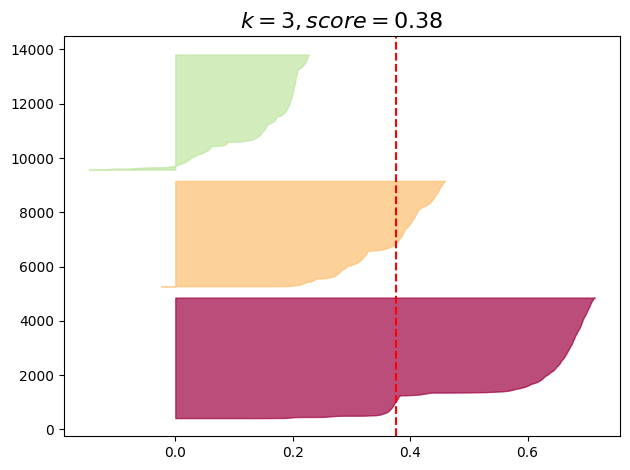

In [42]:
model = clustering_minmax
plt.figure()
plot_silhouette(model, df_data_odd_all_cuantitative_minMaxScaler)
plt.tight_layout()

En este grafico lo que podemos ver es que los clusters, tienen aproximadamente el mismo numero de instancias, de que la gran moyoría  tienen coeficientes de silhoutte positivos, y gran parte de las intancias son  superiores a 0.4 lo que nos sugiere  que puede llegar a ser una buena separación entre los clusters. Podemos apreciar también que el tercer cluster parece ser el que mejor definico está al tener coeficientes de silhoutte bastante altos en su mayoria. La linea roja nos indica el coeficiente de silhoutte medio, que como ya vimos antes es de 0.38

In [43]:
df_data_odd_all_cuantitative_minMaxScaler['CLUSTERS']= labels_minmax
print(df_data_odd_all_cuantitative_minMaxScaler['CLUSTERS'].value_counts())
df_data_odd_all_cuantitative_minMaxScaler.describe()


CLUSTERS
0    4440
2    4240
1    3881
Name: count, dtype: int64


,Age,EducationNum,CapitalGain,HoursPerWeek,MaritalStatus_ Married-AF-spouse,MaritalStatus_ Married-civ-spouse,MaritalStatus_ Married-spouse-absent,MaritalStatus_ Never-married,MaritalStatus_ Separated,MaritalStatus_ Widowed,Relationship_ Not-in-family,Relationship_ Other-relative,Relationship_ Own-child,Relationship_ Unmarried,Relationship_ Wife,Gender_ Male,CLUSTERS
count,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000
mean,0.294668,0.587368,0.015449,0.403071,0.001194,0.353555,0.023247,0.346390,0.052782,0.042751,0.309689,0.053021,0.144654,0.151421,0.057480,0.592548,0.984078
std,0.185635,0.188803,0.084566,0.135547,0.034538,0.478092,0.150692,0.475838,0.223608,0.202304,0.462384,0.224085,0.351766,0.358473,0.232766,0.491380,0.831161
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.150685,0.533333,0.000000,0.346939,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.273973,0.600000,0.000000,0.397959,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
75%,0.410959,0.733333,0.000000,0.479592,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000


In [44]:
df_data_odd_all_cuantitative_minMaxScaler.groupby('CLUSTERS').mean()

,Age,EducationNum,CapitalGain,HoursPerWeek,MaritalStatus_ Married-AF-spouse,MaritalStatus_ Married-civ-spouse,MaritalStatus_ Married-spouse-absent,MaritalStatus_ Never-married,MaritalStatus_ Separated,MaritalStatus_ Widowed,Relationship_ Not-in-family,Relationship_ Other-relative,Relationship_ Own-child,Relationship_ Unmarried,Relationship_ Wife,Gender_ Male
CLUSTERS,,,,,,,,,,,,,,,,
0,0.350636,0.608423,0.032148,0.437208,0.000225,0.999775,0.000000,0.000000,0.000000,0.000000,0.002027,0.020270,0.015315,0.000000,0.160811,0.823423
1,0.302365,0.602611,0.009668,0.409525,0.000000,0.000515,0.036073,0.520227,0.069312,0.068797,1.000000,0.000000,0.000000,0.000000,0.000000,0.526926
2,0.229016,0.551368,0.003253,0.361415,0.003302,0.000000,0.035849,0.550000,0.092925,0.063679,0.000000,0.135849,0.412500,0.448585,0.001887,0.410849


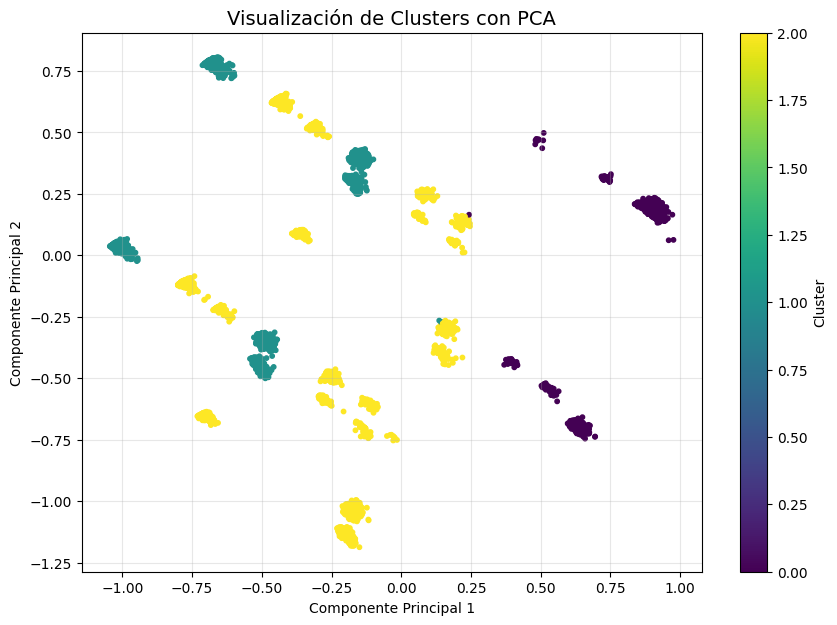

In [45]:
X = df_data_odd_all_cuantitative_minMaxScaler.drop(columns=['CLUSTERS'])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = labels_minmax

plt.figure(figsize=(10, 7))
scatter = plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['Cluster'], cmap='viridis', s=10)
plt.title('Visualización de Clusters con PCA', fontsize=14)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.colorbar(scatter, label='Cluster')
plt.grid(alpha=0.3)
plt.show()

Se puede observar en el PCA, que la agrupación no es del  todo buena , aunque se pueden observar patrones

### Clustering  a partir de  StandardScaler

Hacemos clustering, con 3 clusters, para kmeans.

In [46]:
kmeans_standart= KMeans(n_clusters= 3, random_state= 42, n_init= 40)
clustering_standart= kmeans_standart.fit(df_data_odd_all_cuantitative_standart)
labels_standart= clustering_standart.labels_


Comprobamos si los clusters de realizados tras el escalado de StandardScaler y MinMaxScaler son similares

In [47]:
similarity = adjusted_rand_score(labels_minmax, labels_standart)
print("Similitud entre clusters:", similarity)

Similitud entre clusters: 0.6029486826518928


Hemos aplicado el índice de Rand para comprobar la similitud entre los clusters obtenidos con los datos escalados mediante MinMaxScaler y StandardScaler. En este caso, el valor obtenido es de 0.60, lo que indica que existe una similitud cakra entre ambos clustering. Esto significa que, bastenes  puntos coinciden en el mismo grupo en ambos clusterings, pero existen bastantes los cuales no pertenecen al mismo

In [48]:
silhouette_score_standard= silhouette_score(df_data_odd_all_cuantitative_standart, labels_standart)
silhouette_score_standard

np.float64(0.22357884628925895)

El coeficiente de Silhouette obtenido es de 0.22, lo que indica que la separación entre los clusters es débil. Es decir, los límites entre los grupos no están claramente definidos y existe solapamiento entre ellos. Esto puede deberse a que, como se observa en el describe(), la variable CapitalGain presenta una escala mucho mayor que el resto de las variables. Al tener valores extremos y una gran cantidad de ceros, esta variable adquiere un peso excesivo en el algoritmo K-Means, provocando que la mayoría de las observaciones se agrupen en el mismo cluster. Como consecuencia, los bordes entre clusters se difuminan y la calidad de la separación disminuye

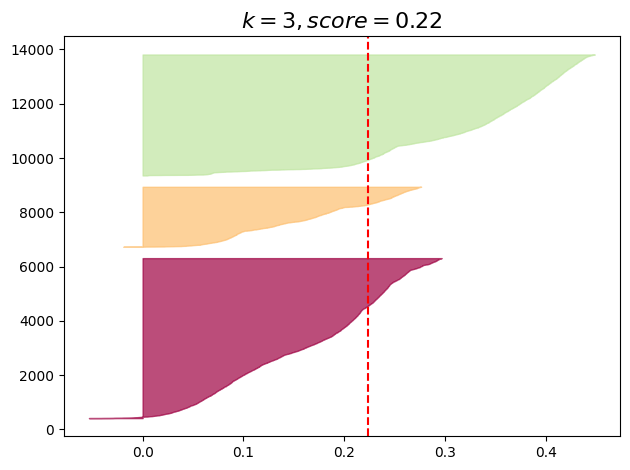

In [49]:
model = clustering_standart
plt.figure()
plot_silhouette(model, df_data_odd_all_cuantitative_standart)
plt.tight_layout()

En este gráfico podemos observar que los tres clusters no presentan una separación clara entre sí. El valor medio del coeficiente de silhoutte es de 0.22, lo que indica que la distancia entre los grupos es débil y que existe cierto solapamiento entre los bordes de los clusters.
Podemos apreciar que el primer cluster (en color verde) muestra una ligera mejor cohesión que el resto, aunque muchos de sus puntos tienen valores bajos de silhoutte, lo que sugiere una distribución difusa. El segundo cluster (en color naranja) presenta una menor compactación, con bastantes puntos cercanos a cero y alguno por debajo de este, lo que indica que algunos podrían estar mal asignados.
La línea roja discontinua marca la media general del coeficiente, y al situarse cerca de 0.22 refleja que el clustering no logra una separación sólida entre los grupos, siendo un resultado débil en términos de calidad de agrupamiento

In [50]:
df_data_odd_all_cuantitative_standart['CLUSTERS']= labels_standart
print(df_data_odd_all_cuantitative_standart['CLUSTERS'].value_counts())
df_data_odd_all_cuantitative_standart.describe()

CLUSTERS
0    5895
2    4456
1    2210
Name: count, dtype: int64


,Age,EducationNum,CapitalGain,HoursPerWeek,MaritalStatus_ Married-AF-spouse,MaritalStatus_ Married-civ-spouse,MaritalStatus_ Married-spouse-absent,MaritalStatus_ Never-married,MaritalStatus_ Separated,MaritalStatus_ Widowed,Relationship_ Not-in-family,Relationship_ Other-relative,Relationship_ Own-child,Relationship_ Unmarried,Relationship_ Wife,Gender_ Male,CLUSTERS
count,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04,12561.000000
mean,-2.353203e-16,5.317333e-17,7.919432e-18,-2.503106e-16,-8.202269e-18,2.715234e-17,1.131347e-17,2.234411e-17,3.620312e-17,3.507177e-17,3.394042e-17,4.299120e-17,-1.357617e-17,8.371971e-17,-3.563744e-17,5.543602e-17,0.885439
std,1.000040e+00,1.000040e+00,1.000040e+00,1.000040e+00,1.000040e+00,1.000040e+00,1.000040e+00,1.000040e+00,1.000040e+00,1.000040e+00,1.000040e+00,1.000040e+00,1.000040e+00,1.000040e+00,1.000040e+00,1.000040e+00,0.900555
min,-1.587414e+00,-3.111138e+00,-1.826932e-01,-2.973772e+00,-3.457745e-02,-7.395412e-01,-1.542719e-01,-7.279859e-01,-2.360586e-01,-2.113307e-01,-6.697924e-01,-2.366219e-01,-4.112392e-01,-4.224225e-01,-2.469512e-01,-1.205935e+00,0.000000
25%,-7.756558e-01,-2.862093e-01,-1.826932e-01,-4.141289e-01,-3.457745e-02,-7.395412e-01,-1.542719e-01,-7.279859e-01,-2.360586e-01,-2.113307e-01,-6.697924e-01,-2.366219e-01,-4.112392e-01,-4.224225e-01,-2.469512e-01,-1.205935e+00,0.000000
50%,-1.114903e-01,6.690680e-02,-1.826932e-01,-3.771074e-02,-3.457745e-02,-7.395412e-01,-1.542719e-01,-7.279859e-01,-2.360586e-01,-2.113307e-01,-6.697924e-01,-2.366219e-01,-4.112392e-01,-4.224225e-01,-2.469512e-01,8.292321e-01,1.000000
75%,6.264713e-01,7.731390e-01,-1.826932e-01,5.645583e-01,-3.457745e-02,1.352190e+00,-1.542719e-01,1.373653e+00,-2.360586e-01,-2.113307e-01,1.493000e+00,-2.366219e-01,-4.112392e-01,-4.224225e-01,-2.469512e-01,8.292321e-01,2.000000
max,3.799706e+00,2.185603e+00,1.164287e+01,4.404023e+00,2.892058e+01,1.352190e+00,6.482062e+00,1.373653e+00,4.236237e+00,4.731919e+00,1.493000e+00,4.226152e+00,2.431675e+00,2.367298e+00,4.049384e+00,8.292321e-01,2.000000


In [51]:
df_data_odd_all_cuantitative_standart.groupby('CLUSTERS').mean()

,Age,EducationNum,CapitalGain,HoursPerWeek,MaritalStatus_ Married-AF-spouse,MaritalStatus_ Married-civ-spouse,MaritalStatus_ Married-spouse-absent,MaritalStatus_ Never-married,MaritalStatus_ Separated,MaritalStatus_ Widowed,Relationship_ Not-in-family,Relationship_ Other-relative,Relationship_ Own-child,Relationship_ Unmarried,Relationship_ Wife,Gender_ Male
CLUSTERS,,,,,,,,,,,,,,,,
0,-0.345810,-0.018212,-0.110815,-0.120452,-0.029666,-0.737057,0.070879,0.642803,0.046163,-0.211331,0.653565,0.177481,0.428373,-0.422422,-0.246951,-0.084263
1,0.316594,-0.183630,-0.133993,-0.192400,-0.034577,-0.739541,0.118989,-0.246796,0.350804,0.989812,-0.408496,-0.180080,-0.394516,1.978505,-0.246951,-0.722468
2,0.300467,0.115167,0.213056,0.254774,0.056395,1.341862,-0.152783,-0.727986,-0.235055,-0.211331,-0.662027,-0.145484,-0.371045,-0.422422,0.449178,0.469789


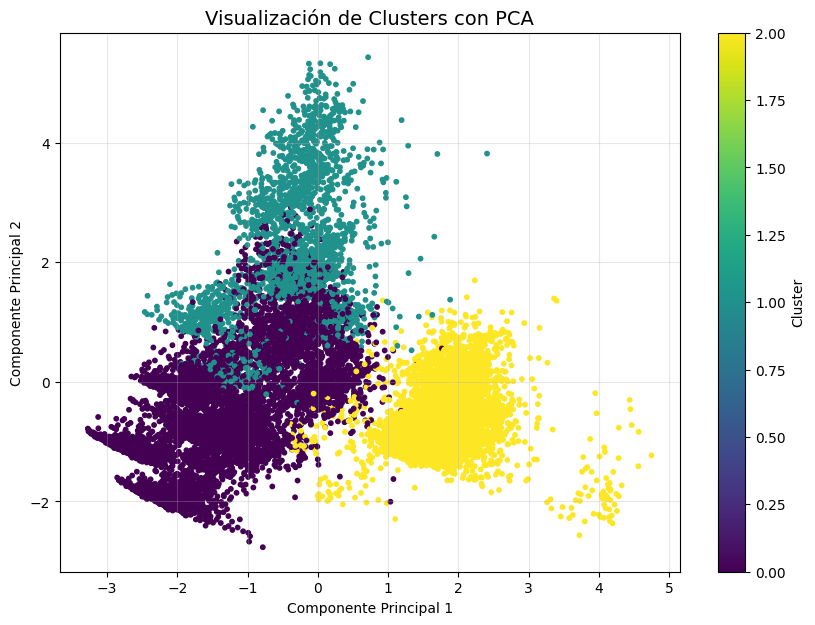

In [52]:
X = df_data_odd_all_cuantitative_standart.drop(columns=['CLUSTERS'])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = labels_standart

plt.figure(figsize=(10, 7))
scatter = plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['Cluster'], cmap='viridis', s=10)
plt.title('Visualización de Clusters con PCA', fontsize=14)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.colorbar(scatter, label='Cluster')
plt.grid(alpha=0.3)
plt.show()

### Clustering  a partir de  MaxAbsScaler

Hacemos 3 cluster con kmeans, para los datos escalados con MaxAbsScaler

In [53]:
kmeans_maxabs= KMeans(n_clusters= 3, random_state= 42, n_init= 40)
clustering_maxabs= kmeans_maxabs.fit(df_data_odd_all_cuantitative_maxabsscaller)
labels_maxabs= clustering_maxabs.labels_


Miramos la similitud entre los clusters, realizados con MinMaxScaler, MaxAbsScaler y StandardScaler

In [54]:
similarity = adjusted_rand_score(labels_minmax, labels_maxabs)
print("Similitud entre clusters de MinMaxScaler y MaxAbsScaler:", similarity)

similarity1 = adjusted_rand_score(labels_standart, labels_maxabs)
print("Similitud entre clusters de StandardScaler y MaxAbsScaler:", similarity1)


Similitud entre clusters de MinMaxScaler y MaxAbsScaler: 1.0
Similitud entre clusters de StandardScaler y MaxAbsScaler: 0.6029486826518928


Hemos calculado el indice de rand, para comparar como de similar es el resultado del clustering aplicado a los datos escalados con MaxAbsScaler, en este caso podemos ver que la relación de los pares que había en el cluster con MinMaxScaler, es indentica ya que el indice es de 1, esto se debe a que como no hay negativos y el mínimo es 0 va a dar el mismo resultado MinMaxScaler que MaxAbsScaler, mientras que con StandardScaler, el indice es de 0.6 al igual que ocurría con MinMaxScaler

In [55]:
silhouette_score_maxabs= silhouette_score(df_data_odd_all_cuantitative_maxabsscaller, labels_maxabs)
silhouette_score_maxabs

np.float64(0.3830354247551136)

El coeficiente de silhoutte obtenido es de 0.38, lo que indica que la separación entre los clusters es algo buena. Aunque no se trata de una separación perfecta, ya que el valor no se acerca completamente a 1, sí refleja que los grupos están algo  bien formados y más o menos  diferenciados entre sí. Esto sugiere que el clustering realizado sobre los datos escalados con MaxAbsScaler ofrece resultados medianamente coherentes y una estructura de clustering aceptable.

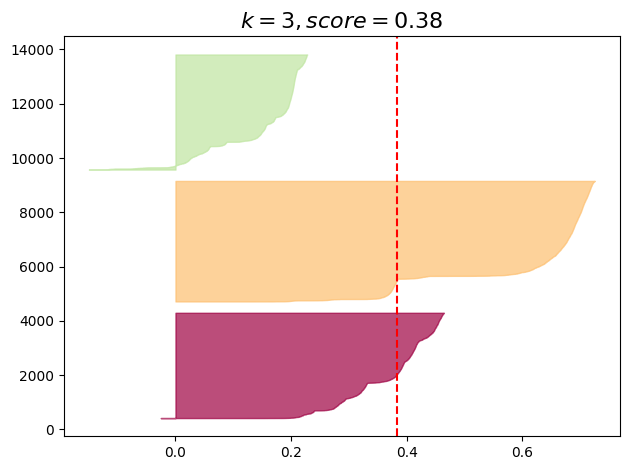

In [56]:
model = clustering_maxabs
plt.figure()
plot_silhouette(model, df_data_odd_all_cuantitative_maxabsscaller)
plt.tight_layout()

En este gráfico podemos observar que los tres clusters presentan un número de instancias relativamente equilibrado y que la mayoría de los puntos tienen coeficientes de silhoutte positivos, lo que indica que están bien asignados a su cluster correspondiente. La mitas de los valores se sitúan por encima de 0.4 (la mayoria del cluster naranja), lo que nos sugiere puede exisitir una separación decente de los cluster.
El segundo cluster (color naranja) parece ser el mejor definido, ya que concentra coeficientes de silhoutte más altos, lo que implica que sus observaciones están más cohesionadas y alejadas de los bordes de los demás clusters.
La línea roja discontinua representa el valor medio del coeficiente de silhoutte (0.38), el cual confirma que el clustering presenta una estructura  que puede ser sólida y bien diferenciada, con algo de   superposición entre los grupos.

In [57]:
df_data_odd_all_cuantitative_maxabsscaller['CLUSTERS']= labels_maxabs
print(df_data_odd_all_cuantitative_maxabsscaller['CLUSTERS'].value_counts())
df_data_odd_all_cuantitative_maxabsscaller.describe()

CLUSTERS
1    4440
2    4240
0    3881
Name: count, dtype: int64


,Age,EducationNum,CapitalGain,HoursPerWeek,MaritalStatus_ Married-AF-spouse,MaritalStatus_ Married-civ-spouse,MaritalStatus_ Married-spouse-absent,MaritalStatus_ Never-married,MaritalStatus_ Separated,MaritalStatus_ Widowed,Relationship_ Not-in-family,Relationship_ Other-relative,Relationship_ Own-child,Relationship_ Unmarried,Relationship_ Wife,Gender_ Male,CLUSTERS
count,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000,12561.000000
mean,0.427898,0.613158,0.015449,0.409100,0.001194,0.353555,0.023247,0.346390,0.052782,0.042751,0.309689,0.053021,0.144654,0.151421,0.057480,0.592548,1.028581
std,0.150571,0.177003,0.084566,0.134178,0.034538,0.478092,0.150692,0.475838,0.223608,0.202304,0.462384,0.224085,0.351766,0.358473,0.232766,0.491380,0.803592
min,0.188889,0.062500,0.000000,0.010101,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.311111,0.562500,0.000000,0.353535,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.411111,0.625000,0.000000,0.404040,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
75%,0.522222,0.750000,0.000000,0.484848,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000


In [58]:
df_data_odd_all_cuantitative_maxabsscaller.groupby('CLUSTERS').mean()

,Age,EducationNum,CapitalGain,HoursPerWeek,MaritalStatus_ Married-AF-spouse,MaritalStatus_ Married-civ-spouse,MaritalStatus_ Married-spouse-absent,MaritalStatus_ Never-married,MaritalStatus_ Separated,MaritalStatus_ Widowed,Relationship_ Not-in-family,Relationship_ Other-relative,Relationship_ Own-child,Relationship_ Unmarried,Relationship_ Wife,Gender_ Male
CLUSTERS,,,,,,,,,,,,,,,,
0,0.434141,0.627448,0.009668,0.415490,0.000000,0.000515,0.036073,0.520227,0.069312,0.068797,1.000000,0.000000,0.000000,0.000000,0.000000,0.526926
1,0.473293,0.632897,0.032148,0.442893,0.000225,0.999775,0.000000,0.000000,0.000000,0.000000,0.002027,0.020270,0.015315,0.000000,0.160811,0.823423
2,0.374646,0.579407,0.003253,0.367865,0.003302,0.000000,0.035849,0.550000,0.092925,0.063679,0.000000,0.135849,0.412500,0.448585,0.001887,0.410849


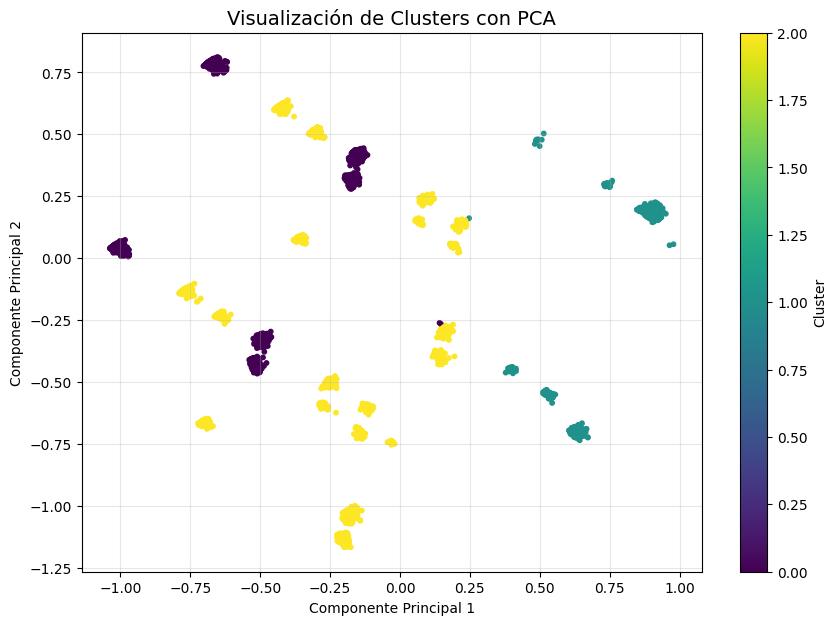

In [59]:
X = df_data_odd_all_cuantitative_maxabsscaller.drop(columns=['CLUSTERS'])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = labels_maxabs

plt.figure(figsize=(10, 7))
scatter = plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['Cluster'], cmap='viridis', s=10)
plt.title('Visualización de Clusters con PCA', fontsize=14)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.colorbar(scatter, label='Cluster')
plt.grid(alpha=0.3)
plt.show()

De nuevo el PCA, nos indica que las agrupaciones no son aceptables

### Clustering  a partir de  NormalizeScaler

Realizamos clustering, con 3 clusters con kmeans, con los datos escalados mediante NormalizeScaler

In [60]:
kmeans_normalize= KMeans(n_clusters= 3, random_state= 42, n_init= 10)
clustering_normalize= kmeans_normalize.fit(df_data_odd_all_cuantitative_normalize)
labels_normalize= clustering_normalize.labels_


In [61]:
silhouette_score_normalize= silhouette_score(df_data_odd_all_cuantitative_normalize, labels_normalize)
silhouette_score_normalize

np.float64(0.5454837085383575)

El coeficiente de silhoutte obtenido es de 0.54, lo que indica que la separación entre los clusters es buena. Aunque no se trata de una separación perfecta, ya que el valor no se acerca completamente a 1, sí refleja que los grupos están bien formados y claramente diferenciados entre sí. Esto sugiere que el clustering realizado sobre los datos escalados con NormalizeScaler ofrece resultados coherentes y una estructura de clustering adecuada.

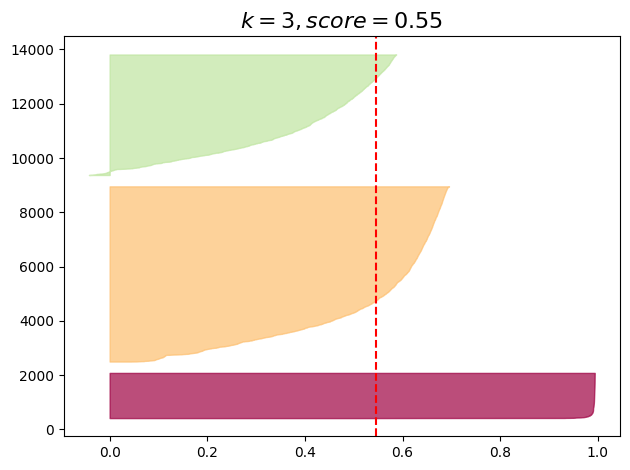

In [62]:
model = clustering_normalize
plt.figure()
plot_silhouette(model, df_data_odd_all_cuantitative_normalize)
plt.tight_layout()

En este gráfico podemos observar que los tres clusters presentan tamaños equilibrados y que la mayoría de las instancias tienen coeficientes de silhoutte positivos, lo que indica que los puntos están correctamente asignados a su grupo. El valor medio del coeficiente de silhoutte es de 0.55, lo que sugiere una  buena separación entre los clusters.
Podemos apreciar que el tercer cluster (en color fuxia) es el que presenta una mejor cohesión interna, con la mayoría de sus valores cerca del 1, aunque tiene menos cantidad de instacias.

In [63]:
df_data_odd_all_cuantitative_normalize['CLUSTERS']= labels_normalize
print(df_data_odd_all_cuantitative_normalize['CLUSTERS'].value_counts())
df_data_odd_all_cuantitative_normalize

CLUSTERS
1    6455
2    4440
0    1666
Name: count, dtype: int64


,Age,EducationNum,CapitalGain,HoursPerWeek,MaritalStatus_ Married-AF-spouse,MaritalStatus_ Married-civ-spouse,MaritalStatus_ Married-spouse-absent,MaritalStatus_ Never-married,MaritalStatus_ Separated,MaritalStatus_ Widowed,Relationship_ Not-in-family,Relationship_ Other-relative,Relationship_ Own-child,Relationship_ Unmarried,Relationship_ Wife,Gender_ Male,CLUSTERS
0,0.679547,0.160945,0.000000,0.715313,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.017883,0.0,0.0,0.000000,0.000000,0.017883,1
1,0.793612,0.104817,0.000000,0.598953,0.0,0.014974,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.014974,2
2,0.553940,0.257186,0.000000,0.791343,0.0,0.019784,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.019784,0.000000,1
3,0.657473,0.248773,0.000000,0.710781,0.0,0.017770,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.017770,0.000000,1
4,0.945812,0.096511,0.000000,0.308837,0.0,0.000000,0.019302,0.000000,0.0,0.000000,0.019302,0.0,0.0,0.000000,0.000000,0.000000,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12556,0.002530,0.000866,0.999992,0.002996,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000067,0.000000,0.000000,0
12557,0.683343,0.308607,0.000000,0.661300,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.022043,0.0,0.0,0.000000,0.000000,0.000000,2
12558,0.872872,0.381881,0.000000,0.300050,0.0,0.000000,0.000000,0.027277,0.0,0.000000,0.027277,0.0,0.0,0.000000,0.000000,0.027277,2
12559,0.560678,0.249190,0.000000,0.789102,0.0,0.020766,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.020766,0.000000,1


In [64]:
df_data_odd_all_cuantitative_normalize.groupby('CLUSTERS').mean()

,Age,EducationNum,CapitalGain,HoursPerWeek,MaritalStatus_ Married-AF-spouse,MaritalStatus_ Married-civ-spouse,MaritalStatus_ Married-spouse-absent,MaritalStatus_ Never-married,MaritalStatus_ Separated,MaritalStatus_ Widowed,Relationship_ Not-in-family,Relationship_ Other-relative,Relationship_ Own-child,Relationship_ Unmarried,Relationship_ Wife,Gender_ Male
CLUSTERS,,,,,,,,,,,,,,,,
0,0.009777,0.002477,0.999562,0.010232,0.000000,0.000113,0.000001,0.000081,0.000007,0.000015,0.000053,0.000009,0.000042,0.000042,0.000012,0.000172
1,0.559347,0.180727,0.000000,0.798426,0.000036,0.004989,0.000436,0.009297,0.000975,0.000166,0.005969,0.001390,0.004019,0.002632,0.000814,0.011197
2,0.800101,0.174597,0.000000,0.544390,0.000015,0.005318,0.000527,0.006289,0.001131,0.001432,0.005517,0.000946,0.003506,0.003474,0.001329,0.008684


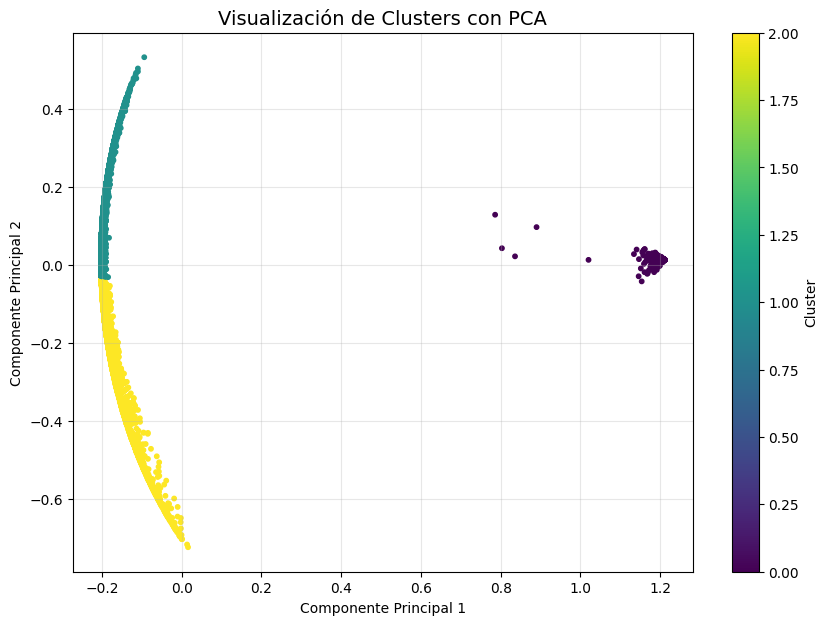

In [65]:
X = df_data_odd_all_cuantitative_normalize.drop(columns=['CLUSTERS'])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = labels_normalize

plt.figure(figsize=(10, 7))
scatter = plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['Cluster'], cmap='viridis', s=10)
plt.title('Visualización de Clusters con PCA', fontsize=14)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.colorbar(scatter, label='Cluster')
plt.grid(alpha=0.3)
plt.show()

Observamos que el PCA nos indica al contrario que el coeficiente de silhoute que las agrupaciones son bastante extrañas, por lo que seguramente no usemos este escalado

Comprobamos la similaridad entre los clusterings con los datos escalados mediante las técnicas: MinMaxScaler, StandardScaler, MaxAbsScaler, RobustScaler y NormalizeScaler

In [66]:
similarity = adjusted_rand_score(labels_minmax, labels_normalize)
print("Similitud entre clusters de MinMaxScaler y NormalizeScaler:", similarity)

similarity1 = adjusted_rand_score(labels_standart, labels_normalize)
print("Similitud entre clusters de StandardScaler y NormalizeScaler:", similarity1)

similarity2 = adjusted_rand_score(labels_maxabs, labels_normalize)
print("Similitud entre clusters de MaxAbsScaler y NormalizeScaler:", similarity2)

Similitud entre clusters de MinMaxScaler y NormalizeScaler: 0.012668541982284478
Similitud entre clusters de StandardScaler y NormalizeScaler: 0.03852436764749208
Similitud entre clusters de MaxAbsScaler y NormalizeScaler: 0.012668541982284478


Utilizamos el índice de Rand, como en los casos anteriores, para analizar la similitud entre los distintos clusterings. En este caso, los resultados más parecidos se obtienen entre MinMaxScaler y MaxAbsScaler, que son casi idénticos, lo cual tiene sentido ya que ambos presentan coeficientes de silhoutte similares y una estructura de clusters bastante parecida.
Por otro lado, la similitud con el StandardScaler es bastante menor, lo que se puede explicar porque, como vimos en su gráfico de silhoutte, los clusters tenían tamaños desiguales y una separación menos uniforme, lo que provoca que la relación de los pares de instancias difiera respecto a los otros tres escalados

Por último haremos un cluster a los datos sin escalar

In [67]:

#Hacemos el clustering sin escalar
kmeans= KMeans(n_clusters= 3, random_state= 42, n_init= 10)
clustering= kmeans.fit(df_data_odd_all_cuantitative)
labels= clustering.labels_
# Añadimos las etiquetas de clustering al DataFrame original


In [68]:
silhouette_score_no_scale= silhouette_score(df_data_odd_all_cuantitative, labels)
silhouette_score_no_scale

np.float64(0.9229834153683889)

El coeficiente de silhoutte obtenido es de 0.92, lo que en principio indicaría una separación muy clara entre los clusters. Sin embargo, al observar el número de instancias en cada grupo, vemos que la mayoría de los datos se concentran en el primer cluster, mientras que los demás contienen muy pocos puntos. Esto sugiere que el alto valor del silhoutte no se debe a una buena estructura de separación, sino a un desequilibrio en el tamaño de los clusters, que hace que la mayoría de las distancias se calculen dentro del mismo cluster dominante.

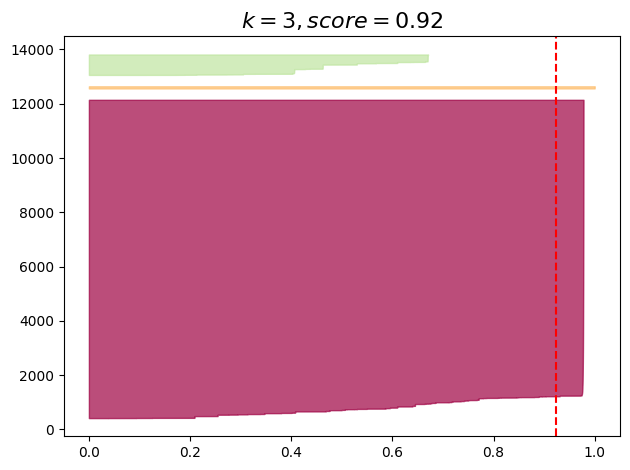

In [69]:
model = clustering
plt.figure()
plot_silhouette(model, df_data_odd_all_cuantitative)
plt.tight_layout()

En este gráfico podemos observar que el coeficiente de silhoutte es de 0.92, lo que a primera vista podría parecer un resultado excelente, ya que indica una separación casi perfecta entre los clusters. Sin embargo, si analizamos la distribución de las instancias, vemos que la gran mayoría de los datos pertenecen al primer cluster (en color morado), mientras que los otros dos grupos son muy pequeños.
Esto sugiere que el modelo no ha conseguido una agrupación equilibrada, sino que ha concentrado casi todos los puntos en un único cluster. Por tanto, el alto valor del silhoutte no refleja una buena calidad de clustering, sino más bien un desequilibrio en el tamaño de los grupos, lo que hace que las distancias internas sean muy pequeñas y el coeficiente se dispare artificialmente.

In [70]:
df_data_odd_all_cuantitative['CLUSTERING']= labels

print(df_data_odd_all_cuantitative['CLUSTERING'].value_counts())
df_data_odd_all_cuantitative


CLUSTERING
0    11728
2      753
1       80
Name: count, dtype: int64


,Age,EducationNum,CapitalGain,HoursPerWeek,MaritalStatus_ Married-AF-spouse,MaritalStatus_ Married-civ-spouse,MaritalStatus_ Married-spouse-absent,MaritalStatus_ Never-married,MaritalStatus_ Separated,MaritalStatus_ Widowed,Relationship_ Not-in-family,Relationship_ Other-relative,Relationship_ Own-child,Relationship_ Unmarried,Relationship_ Wife,Gender_ Male,CLUSTERING
0,38,9,0,40,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0
1,53,7,0,40,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
2,28,13,0,40,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
3,37,14,0,40,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
4,49,5,0,16,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12556,38,13,15020,45,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2
12557,31,14,0,30,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0
12558,32,14,0,11,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0
12559,27,12,0,38,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0


In [71]:
df_data_odd_all_cuantitative.groupby('CLUSTERING').mean()

,Age,EducationNum,CapitalGain,HoursPerWeek,MaritalStatus_ Married-AF-spouse,MaritalStatus_ Married-civ-spouse,MaritalStatus_ Married-spouse-absent,MaritalStatus_ Never-married,MaritalStatus_ Separated,MaritalStatus_ Widowed,Relationship_ Not-in-family,Relationship_ Other-relative,Relationship_ Own-child,Relationship_ Unmarried,Relationship_ Wife,Gender_ Male
CLUSTERING,,,,,,,,,,,,,,,,
0,38.133868,9.665246,239.275068,40.110846,0.001279,0.327422,0.024557,0.361272,0.055252,0.044424,0.317190,0.056361,0.153223,0.158680,0.055167,0.577677
1,44.712500,12.825000,99999.000000,49.237500,0.000000,0.850000,0.012500,0.050000,0.025000,0.000000,0.125000,0.000000,0.012500,0.012500,0.100000,0.850000
2,43.722444,11.752988,11419.875166,45.648074,0.000000,0.707835,0.003984,0.146082,0.017264,0.021248,0.212483,0.006640,0.025232,0.053121,0.088977,0.796813


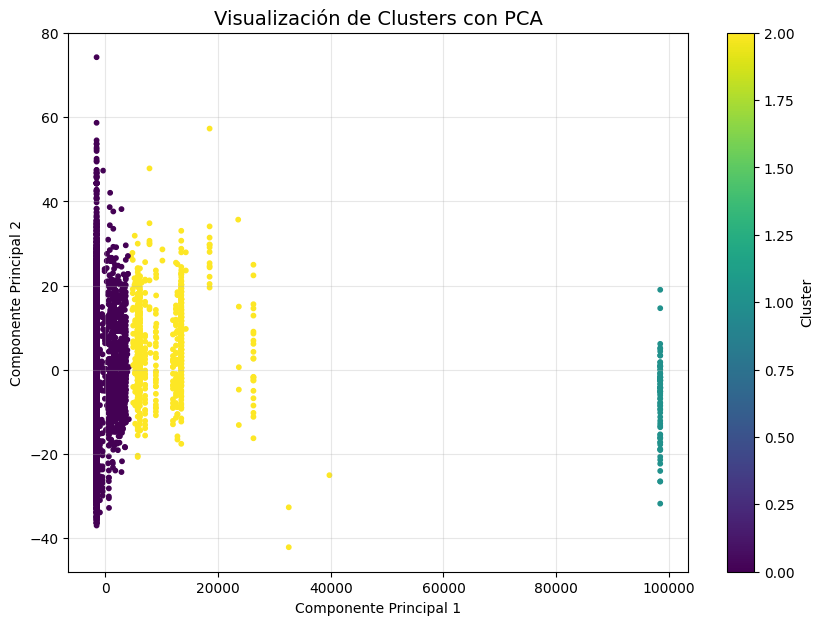

In [72]:
X = df_data_odd_all_cuantitative.drop(columns=['CLUSTERING'])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = labels

plt.figure(figsize=(10, 7))
scatter = plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['Cluster'], cmap='viridis', s=10)
plt.title('Visualización de Clusters con PCA', fontsize=14)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.colorbar(scatter, label='Cluster')
plt.grid(alpha=0.3)
plt.show()

El PCA nos muestra grupos distinguidos pero algunos juntos, debido a que la variable CapitalGain habrá dominado sobre las otras variables

In [73]:
similarity = adjusted_rand_score(labels_minmax, labels)
print("Similitud entre clusters de MinMaxScaler y sin escalar:", similarity)

similarity1 = adjusted_rand_score(labels_standart, labels)
print("Similitud entre clusters de StandardScaler y sin escalar:", similarity1)

similarity2 = adjusted_rand_score(labels_maxabs, labels)
print("Similitud entre clusters de MaxAbsScaler y sin escalar:", similarity2)

similarity3= adjusted_rand_score(labels_normalize, labels)
print("Similitud entre clusters de NormalizeScaler y sin escalar:", similarity2)


Similitud entre clusters de MinMaxScaler y sin escalar: 0.002067646907873122
Similitud entre clusters de StandardScaler y sin escalar: 0.009376542999298255
Similitud entre clusters de MaxAbsScaler y sin escalar: 0.002067646907873122
Similitud entre clusters de NormalizeScaler y sin escalar: 0.002067646907873122


Utilizamos el índice de Rand, como en los casos anteriores, para analizar la similitud entre los distintos clusterings. En este caso, podemos observar que los resultados obtenidos al aplicar escalado y los datos sin escalar presentan una similitud prácticamente nula o incluso ligeramente negativa, lo que indica que los agrupamientos generados son completamente diferentes entre sí.
Esto tiene sentido, ya que el clustering realizado sin escalar los datos estaba muy influenciado por las variables con mayor magnitud —especialmente CapitalGain—, lo que provocó que la mayoría de las instancias se concentraran en un único cluster. En cambio, al aplicar los distintos métodos de escalado, las variables quedaron normalizadas y en la misma escala, lo que cambió por completo la estructura de los grupos formados.

Una vez realizado el analisis y el clustering para con todas las variables escaladas de la misma manera y ver que las desviaciones típicas no son constantes en la mayoria de los casos y que en algún escalado la escala no es buena, hemos decidido mezclar escalados en las variables.

In [74]:
categoricas_transformadas

,MaritalStatus_ Married-AF-spouse,MaritalStatus_ Married-civ-spouse,MaritalStatus_ Married-spouse-absent,MaritalStatus_ Never-married,MaritalStatus_ Separated,MaritalStatus_ Widowed,Relationship_ Not-in-family,Relationship_ Other-relative,Relationship_ Own-child,Relationship_ Unmarried,Relationship_ Wife,Gender_ Male,Education_transformed
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,9.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,7.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,13.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,14.0
4,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12556,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,13.0
12557,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,14.0
12558,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,14.0
12559,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,11.0


In [75]:
categoricas_transformadas.drop('Education_transformed', inplace= True, axis=1)
normalizer_categoric = preprocessing.StandardScaler()
normalizer_categoric.fit(categoricas_transformadas)
normalize_scale_categoric = normalizer_categoric.transform(categoricas_transformadas)
df_normalize_scale_categoric = pd.DataFrame(
    normalize_scale_categoric,
    columns=categoricas_transformadas.columns,
    index=categoricas_transformadas.index
)

Gender=df_normalize_scale_categoric['Gender_ Male']/2
Relation=df_normalize_scale_categoric[['Relationship_ Not-in-family','Relationship_ Other-relative','Relationship_ Own-child','Relationship_ Unmarried','Relationship_ Wife']]/6
MaritalStatus=df_normalize_scale_categoric[['MaritalStatus_ Married-AF-spouse','MaritalStatus_ Married-civ-spouse','MaritalStatus_ Married-spouse-absent','MaritalStatus_ Never-married','MaritalStatus_ Separated','MaritalStatus_ Widowed']]/7
df_normalize_scale_categoric=pd.concat([Gender, Relation, MaritalStatus], axis=1)
df_normalize_scale_categoric.describe()


,Gender_ Male,Relationship_ Not-in-family,Relationship_ Other-relative,Relationship_ Own-child,Relationship_ Unmarried,Relationship_ Wife,MaritalStatus_ Married-AF-spouse,MaritalStatus_ Married-civ-spouse,MaritalStatus_ Married-spouse-absent,MaritalStatus_ Never-married,MaritalStatus_ Separated,MaritalStatus_ Widowed
count,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04
mean,2.771801e-17,6.505248e-18,-3.111205e-18,1.385901e-17,4.525390e-18,-2.545532e-18,3.535461e-19,8.202269e-18,-5.373900e-18,-7.070921e-20,7.070921e-18,1.838440e-18
std,5.000199e-01,1.666733e-01,1.666733e-01,1.666733e-01,1.666733e-01,1.666733e-01,1.428628e-01,1.428628e-01,1.428628e-01,1.428628e-01,1.428628e-01,1.428628e-01
min,-6.029675e-01,-1.116321e-01,-3.943698e-02,-6.853986e-02,-7.040375e-02,-4.115853e-02,-4.939636e-03,-1.056487e-01,-2.203884e-02,-1.039980e-01,-3.372265e-02,-3.019010e-02
25%,-6.029675e-01,-1.116321e-01,-3.943698e-02,-6.853986e-02,-7.040375e-02,-4.115853e-02,-4.939636e-03,-1.056487e-01,-2.203884e-02,-1.039980e-01,-3.372265e-02,-3.019010e-02
50%,4.146161e-01,-1.116321e-01,-3.943698e-02,-6.853986e-02,-7.040375e-02,-4.115853e-02,-4.939636e-03,-1.056487e-01,-2.203884e-02,-1.039980e-01,-3.372265e-02,-3.019010e-02
75%,4.146161e-01,2.488333e-01,-3.943698e-02,-6.853986e-02,-7.040375e-02,-4.115853e-02,-4.939636e-03,1.931700e-01,-2.203884e-02,1.962361e-01,-3.372265e-02,-3.019010e-02
max,4.146161e-01,2.488333e-01,7.043587e-01,4.052792e-01,3.945497e-01,6.748973e-01,4.131512e+00,1.931700e-01,9.260088e-01,1.962361e-01,6.051767e-01,6.759885e-01


In [76]:
cuantitative_no_capital= data_odd[['Age', 'EducationNum', 'HoursPerWeek']]
robustscaler_cuatitative_no_capital = preprocessing.RobustScaler().fit(cuantitative_no_capital)
robust_cuatitative_no_capital= robustscaler_cuatitative_no_capital.transform(cuantitative_no_capital)
df_robust_cuantitative_no_capital= pd.DataFrame(robust_cuatitative_no_capital, columns= cuantitative_no_capital.columns, index= cuantitative_no_capital.index)
df_robust_cuantitative_no_capital.describe()

,Age,EducationNum,HoursPerWeek
count,12561.000000,12561.000000,12561.000000
mean,0.079515,-0.063158,0.038532
std,0.713230,0.944014,1.021818
min,-1.052632,-3.000000,-3.000000
25%,-0.473684,-0.333333,-0.384615
50%,0.000000,0.000000,0.000000
75%,0.526316,0.666667,0.615385
max,2.789474,2.000000,4.538462


In [77]:
capital_gain= data_odd[['CapitalGain']]
normalizer_capital= preprocessing.MaxAbsScaler().fit(capital_gain)
normalize_capital_gain= normalizer_capital.transform (capital_gain)
df_maxabs_capital_gain= pd.DataFrame(normalize_capital_gain, columns= capital_gain.columns, index= capital_gain.index)
df_maxabs_capital_gain.describe()

,CapitalGain
count,12561.000000
mean,0.015449
std,0.084566
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [78]:
df_data_different_scale= pd.concat([df_normalize_scale_categoric, df_robust_cuantitative_no_capital, df_maxabs_capital_gain], axis=1)
df_data_different_scale.describe()

,Gender_ Male,Relationship_ Not-in-family,Relationship_ Other-relative,Relationship_ Own-child,Relationship_ Unmarried,Relationship_ Wife,MaritalStatus_ Married-AF-spouse,MaritalStatus_ Married-civ-spouse,MaritalStatus_ Married-spouse-absent,MaritalStatus_ Never-married,MaritalStatus_ Separated,MaritalStatus_ Widowed,Age,EducationNum,HoursPerWeek,CapitalGain
count,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04,1.256100e+04,12561.000000,12561.000000,12561.000000,12561.000000
mean,2.771801e-17,6.505248e-18,-3.111205e-18,1.385901e-17,4.525390e-18,-2.545532e-18,3.535461e-19,8.202269e-18,-5.373900e-18,-7.070921e-20,7.070921e-18,1.838440e-18,0.079515,-0.063158,0.038532,0.015449
std,5.000199e-01,1.666733e-01,1.666733e-01,1.666733e-01,1.666733e-01,1.666733e-01,1.428628e-01,1.428628e-01,1.428628e-01,1.428628e-01,1.428628e-01,1.428628e-01,0.713230,0.944014,1.021818,0.084566
min,-6.029675e-01,-1.116321e-01,-3.943698e-02,-6.853986e-02,-7.040375e-02,-4.115853e-02,-4.939636e-03,-1.056487e-01,-2.203884e-02,-1.039980e-01,-3.372265e-02,-3.019010e-02,-1.052632,-3.000000,-3.000000,0.000000
25%,-6.029675e-01,-1.116321e-01,-3.943698e-02,-6.853986e-02,-7.040375e-02,-4.115853e-02,-4.939636e-03,-1.056487e-01,-2.203884e-02,-1.039980e-01,-3.372265e-02,-3.019010e-02,-0.473684,-0.333333,-0.384615,0.000000
50%,4.146161e-01,-1.116321e-01,-3.943698e-02,-6.853986e-02,-7.040375e-02,-4.115853e-02,-4.939636e-03,-1.056487e-01,-2.203884e-02,-1.039980e-01,-3.372265e-02,-3.019010e-02,0.000000,0.000000,0.000000,0.000000
75%,4.146161e-01,2.488333e-01,-3.943698e-02,-6.853986e-02,-7.040375e-02,-4.115853e-02,-4.939636e-03,1.931700e-01,-2.203884e-02,1.962361e-01,-3.372265e-02,-3.019010e-02,0.526316,0.666667,0.615385,0.000000
max,4.146161e-01,2.488333e-01,7.043587e-01,4.052792e-01,3.945497e-01,6.748973e-01,4.131512e+00,1.931700e-01,9.260088e-01,1.962361e-01,6.051767e-01,6.759885e-01,2.789474,2.000000,4.538462,1.000000


In [79]:
kmeans_different_scale= KMeans(n_clusters= 3, random_state= 42, n_init= 40)
clustering_different_scale= kmeans_different_scale.fit(df_data_different_scale)
labels_different_scale= clustering_different_scale.labels_
df_data_different_scale['CLUSTERS']= labels_different_scale
print(df_data_different_scale['CLUSTERS'].value_counts())
df_data_different_scale.drop(['CLUSTERS'], axis=1, inplace=True)


CLUSTERS
0    5693
2    4447
1    2421
Name: count, dtype: int64


In [80]:
silhouette_score_different_scale= silhouette_score(df_data_different_scale, labels_different_scale)
silhouette_score_different_scale

np.float64(0.19637508667510145)

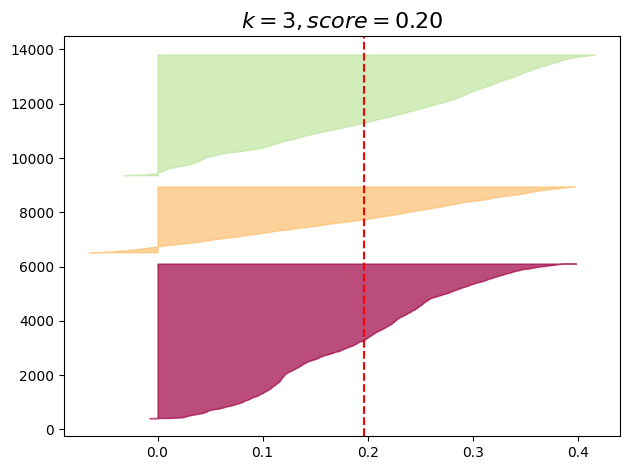

In [81]:
model = kmeans_different_scale
plt.figure()
plot_silhouette(model, df_data_different_scale)
plt.tight_layout()

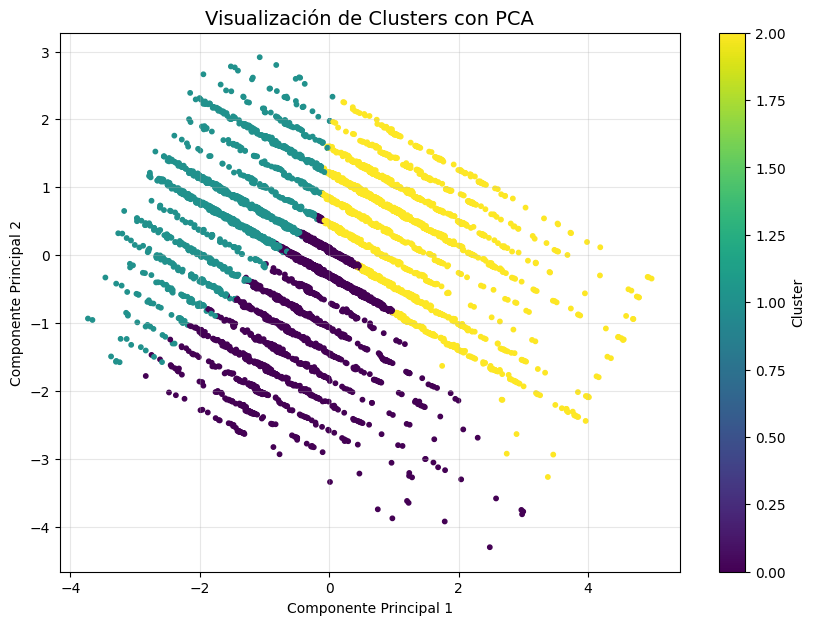

In [82]:
X=df_data_different_scale
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = labels_different_scale

plt.figure(figsize=(10, 7))
scatter = plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['Cluster'], cmap='viridis', s=10)
plt.title('Visualización de Clusters con PCA', fontsize=14)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.colorbar(scatter, label='Cluster')
plt.grid(alpha=0.3)
plt.show()


Una vez analizado con k=3, procedemos al análisis por si acaso es más interesante usar otro k

In [83]:
Ks = range(1, 15)
kmeans_per_k = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(df_data_different_scale) for k in Ks]

Elbow pllot

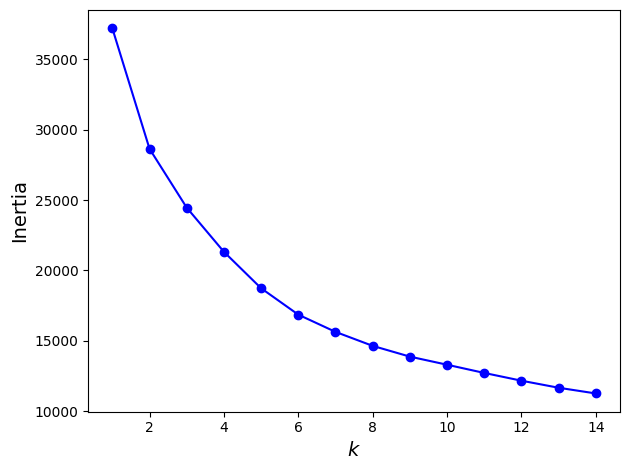

In [84]:
inertias = [model.inertia_ for model in kmeans_per_k]
plt.figure()
plt.plot(Ks, inertias, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Inertia", fontsize=14)
plt.tight_layout()
plt.show()

En dicho gráfico podemos ver que a medida que el número de k es más alto, la inertia es inversamente proporcional

Otra manera de obtener el número de k ideal es graficando los diferente coefiecientes silhoutte, de manera que buscamos el más alto y más simple, es decir, menor número de agrupaciones.

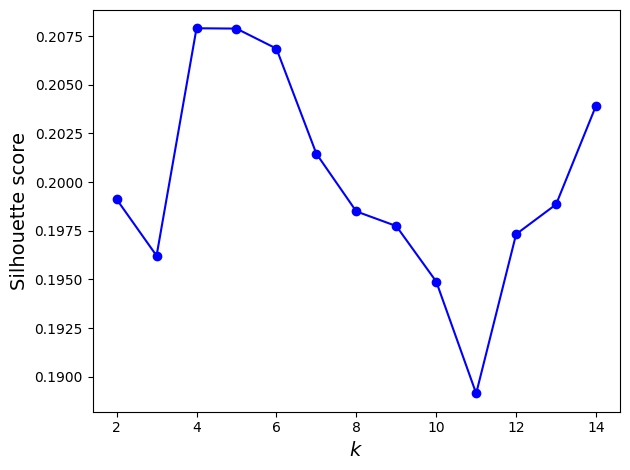

In [85]:
#Gráfica del silhouette score para diferentes valores de k
silhouette_scores = [silhouette_score(df_data_different_scale, model.labels_) for model in kmeans_per_k[1:]]

plt.figure()
plt.plot(Ks[1:], silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.tight_layout()
plt.show()

Como podemos obsrevar, el gráfico no es monótono creciente , por lo que nos quedamos con el k=4 como la solución más óptima para Kmeans.

## Hierarchical

El siguiente método de agrupación que vamos a analizar es el jerárquico, donde analizaremos los diferentes tipos de enlaces


Función para dibujar los dendogramas

In [86]:
def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)


### Enlace=complete

Creamos el modelo correspondiente

In [87]:
hierarchical = AgglomerativeClustering(distance_threshold=0,
                                        n_clusters=None,
                                        linkage="complete").fit(df_data_different_scale)


Representamos graficamente el resultado

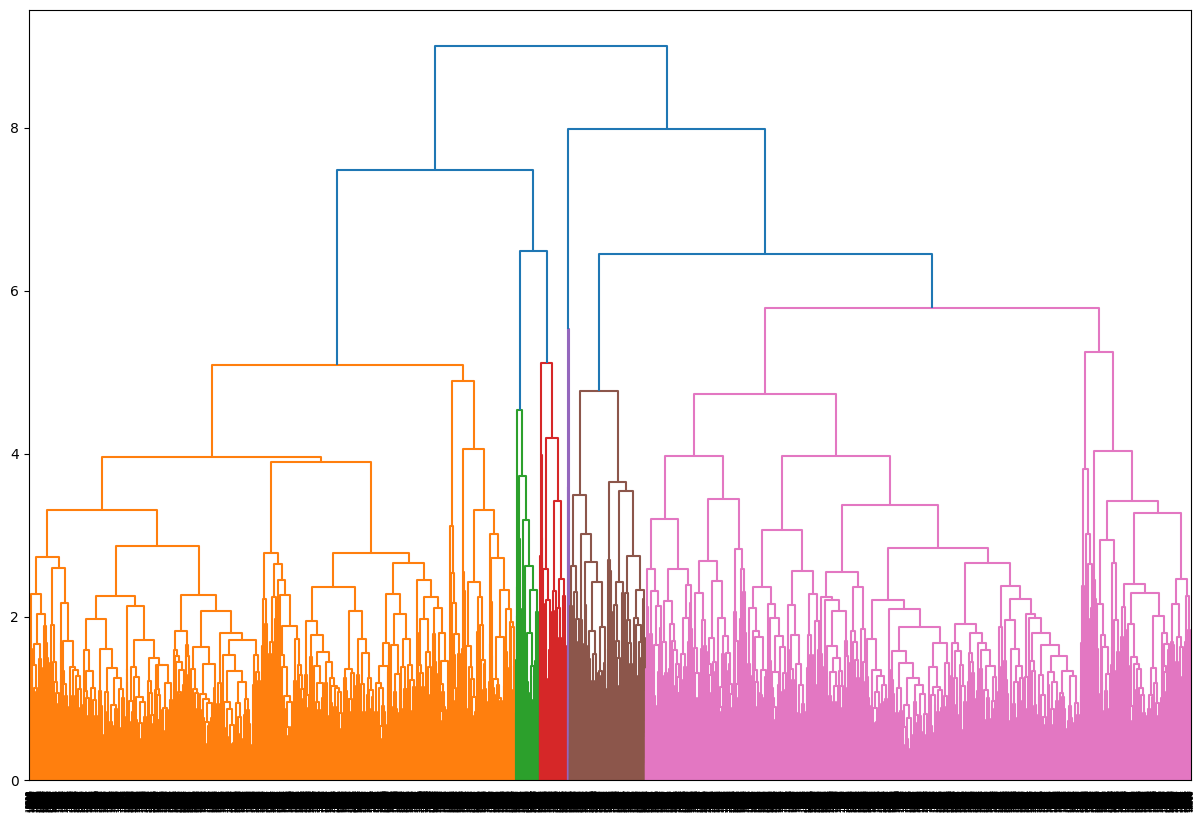

In [88]:
plt.figure(figsize=(15, 10))
plot_dendrogram(hierarchical)
plt.show()

Analizamos el silhouette para observar como varía según los cluster

In [89]:
for k in range(2, 9):
    model = AgglomerativeClustering(n_clusters=k, linkage="complete").fit(df_data_different_scale)
    sil = silhouette_score(df_data_different_scale, model.labels_)
    print(f"n_clusters={k}, silhouette={sil:.3f}")

n_clusters=2, silhouette=0.182
n_clusters=3, silhouette=0.184
n_clusters=4, silhouette=0.162
n_clusters=5, silhouette=0.143
n_clusters=6, silhouette=0.136
n_clusters=7, silhouette=0.139
n_clusters=8, silhouette=0.139


### Enlace=average


Creamos el modelo correspondiente

In [ ]:
hierarchical = AgglomerativeClustering(distance_threshold=0,
                                        n_clusters=None,
                                        linkage="average").fit(df_data_different_scale)


Representamos graficamente el resultado

In [ ]:
plt.figure(figsize=(15, 10))
plot_dendrogram(hierarchical)
plt.show()

Analizamos el silhouette para observar como varía según los cluster

In [ ]:
for k in range(2, 9):
    model = AgglomerativeClustering(n_clusters=k, linkage="average").fit(df_data_different_scale)
    sil = silhouette_score(df_data_different_scale, model.labels_)
    print(f"n_clusters={k}, silhouette={sil:.3f}")

### Enlace=single

Creamos el modelo correspondiente

In [ ]:
hierarchical = AgglomerativeClustering(distance_threshold=0,
                                        n_clusters=None,
                                        linkage="single").fit(df_data_different_scale)


Representamos graficamente el resultado

In [ ]:
plt.figure(figsize=(15, 10))
plot_dendrogram(hierarchical)
plt.show()

Analizamos el silhouette para observar como varía según los cluster

In [ ]:
for k in range(2, 9):
    model = AgglomerativeClustering(n_clusters=k, linkage="single").fit(df_data_different_scale)
    sil = silhouette_score(df_data_different_scale, model.labels_)
    print(f"n_clusters={k}, silhouette={sil:.3f}")

### Enlace=ward

Creamos el modelo correspondiente

In [ ]:
hierarchical = AgglomerativeClustering(distance_threshold=0,
                                        n_clusters=None,
                                        linkage="ward").fit(df_data_different_scale)


Representamos graficamente el resultado

In [ ]:
plt.figure(figsize=(15, 10))
plot_dendrogram(hierarchical)
plt.show()

Analizamos el silhouette para observar como varía según los cluster

In [ ]:
for k in range(2, 9):
    model = AgglomerativeClustering(n_clusters=k, linkage="ward").fit(df_data_different_scale)
    sil = silhouette_score(df_data_different_scale, model.labels_)
    print(f"n_clusters={k}, silhouette={sil:.3f}")


## DBSCAN

En tercer lugar, analizaremos el método de agrumaiento de DBSCAN.

In [ ]:
#Creamos el modelo DBSCAN con los mejores parámetros encontrados
dbscan2 = DBSCAN(min_samples = 20, eps=  0.9)
dbscan_data = dbscan2.fit(df_data_different_scale)
df_data_different_scale['CLUSTERS']= dbscan_data.labels_

#Mostramos el número de elementos en cada cluster
print(df_data_different_scale['CLUSTERS'].value_counts())

#Eliminamos la columna CLUSTERS para dejar el dataframe como estaba
df_data_different_scale.drop('CLUSTERS', axis=1, inplace=True)



Analizamos el silhoutte score que tiene

In [ ]:
silhouette_score_dbscan= silhouette_score(df_data_different_scale, dbscan_data.labels_)
silhouette_score_dbscan

Representamos su PCA para obervar  como se distribuyen los cluster, ya que no podemos hacerlo en 2D como hemos hecho muchas vees en clase

In [ ]:
df_data_different_scale
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_data_different_scale)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = dbscan_data.labels_

plt.figure(figsize=(10, 7))
scatter = plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['Cluster'], cmap='viridis', s=10)
plt.title('Visualización de Clusters con PCA', fontsize=14)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.colorbar(scatter, label='Cluster')
plt.grid(alpha=0.3)
plt.show()

## GAUSS

Por último, aplicamos el último método de análisis.

In [ ]:
def gmm_bic_score(estimator, X):
    """Callable to pass to GridSearchCV that will use the BIC score."""
    # Make it negative since GridSearchCV expects a score to maximize
    return -estimator.bic(X)

param_grid = {
    "n_components": Ks,
    "covariance_type": ["spherical", "tied", "diag", "full"],
}
busqueda = GridSearchCV(
    GaussianMixture(), param_grid=param_grid, scoring=gmm_bic_score
)
busqueda.fit(df_data_different_scale)

Usamos una función para encontrar los mejores parametros.

In [ ]:
df = pd.DataFrame(busqueda.cv_results_)[
    ["param_n_components", "param_covariance_type", "mean_test_score"]
]
df["mean_test_score"] = -df["mean_test_score"]
df = df.rename(
    columns={
        "param_n_components": "Number of components",
        "param_covariance_type": "Type of covariance",
        "mean_test_score": "BIC score",
    })
df.sort_values(by="BIC score").head()

In [ ]:
labels= busqueda.best_estimator_.predict(df_data_different_scale)
df_data_different_scale['CLUSTERS']= labels
print(df_data_different_scale['CLUSTERS'].value_counts())
df_data_different_scale.drop(['CLUSTERS'], axis=1, inplace=True)


In [ ]:
silhouette_score_different_scale= silhouette_score(df_data_different_scale, labels)
silhouette_score_different_scale

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_data_different_scale)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = labels

plt.figure(figsize=(10, 7))
scatter = plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['Cluster'], cmap='viridis', s=10)
plt.title('Visualización de Clusters con PCA', fontsize=14)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.colorbar(scatter, label='Cluster')
plt.grid(alpha=0.3)
plt.show()

## Análisis del mejor método

Tras observar los diferenes métodos, hemos llegado a la conclusión de que Kmeans con número de cluster K=4, es el método más adecuado para buscar una agrupación natural en los datos proporcionados.

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
axes = axes.flatten()
df_data_different_scale['CLUSTERS']= kmeans_per_k[3].labels_
categoricas_transformadas['CLUSTERS']=kmeans_per_k[3].labels_

variables = [col for col in df_data_different_scale.columns if col != 'CLUSTERS']

for i, var in enumerate(variables):
    if var in ['Age', 'EducationNum', 'CapitalGain', 'HoursPerWeek']:
        sns.boxplot(x='CLUSTERS', y=var, data=df_data_different_scale, ax=axes[i])
        axes[i].set_title(f'{var} por cluster')
        axes[i].set_xlabel('Cluster')
        axes[i].set_ylabel(var)
    else:
        grouped_df = categoricas_transformadas.groupby('CLUSTERS')[var].sum().reset_index(name='count')
        grouped_df['count'] = grouped_df['count']
        sns.barplot(x='CLUSTERS', y='count', data=grouped_df, ax=axes[i], errorbar= None)
        axes[i].set_xlabel('Cluster')
        axes[i].set_ylabel('Frecuencia (escala relativa)')

for j in range(len(variables), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [ ]:
sns.boxplot(x='CLUSTERS', y='EducationNum', data=df_data_different_scale)


In [ ]:
sns.boxplot(x='CLUSTERS', y='Age', data=df_data_different_scale)


In [ ]:
sns.boxplot(x='CLUSTERS', y='HoursPerWeek', data=df_data_different_scale)


In [ ]:
def scatters(data, h=None, pal=None):
    fig, (ax1, ax2, ax3) = plt.subplots(3,1, figsize=(8,8))
    sns.scatterplot(x="Age",y="HoursPerWeek", hue=h, palette=pal, data=data, ax=ax1)
    sns.scatterplot(x="Age",y="EducationNum", hue=h, palette=pal, data=data, ax=ax2)
    sns.scatterplot(x="HoursPerWeek",y="EducationNum", hue=h, palette=pal, data=data, ax=ax3)
    plt.tight_layout()

scatters(df_data_different_scale, 'CLUSTERS')

In [ ]:
df_data_different_scale.groupby('CLUSTERS').mean()

In [ ]:
df_data_different_scale.drop(['CLUSTERS'], axis=1, inplace=True)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_data_different_scale)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = kmeans_per_k[3].labels_

plt.figure(figsize=(10, 7))
scatter = plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['Cluster'], cmap='viridis', s=10)
plt.title('Visualización de Clusters con PCA', fontsize=14)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.colorbar(scatter, label='Cluster')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
silhouette_score_kmeans4= silhouette_score(df_data_different_scale, kmeans_per_k[3].labels_)
silhouette_score_kmeans4

In [ ]:
model = kmeans_per_k[3]
plt.figure()
plot_silhouette(model, df_data_different_scale)
plt.tight_layout()